# Классификация места залежей нефти и газа

Нефтегазовая отрасль имеет сложную технологическую цепочку, которая начинается с геологической разведки и заканчивается доставкой нефти и газа потребителям. Одной из важных задач является определение места залежей — на суше или в море — на основе различных параметров.

Нашей задачей является разработка алгоритма машинного обучения, который позволит классифицировать место залежей нефти и газа.

## Резултат разработки и выводы 
Было разработано несколько алгоритмов машинного обучения для классификации места залежей нефти и газа по признаку onshore/offshore (на берегу, в море/океане). 

Наилучший результат `publicScore: 0.94916` показал алгоритм на основе `sklearn.ensemble.RandomForestClassifier`.

Решающим фактором стало подробное ознакомление с предметной областью и изучение справочных материалов. Понимание предметной области позволило обогатить датасет данными из справочников, сформулировать признаки для бассейнов (бассейны могут залегать и под морем и под сушей, а информация об этом есть в обучающей выборке) и признаки, основанные на координатах:
1. Самым значимым признаком оказался `basin_location_inferred` - это, по сути, расчитанное по месторождениям месторасположение бассейна. Некоторые бассейны встречаются для разных месторождений по нескольку раз. Поэтому, удалось разработать признак, который указывает на то, как залегает бассейн.
2. Вторым по значимости оказался процент площади, занимаемый водой в радиусе 2км вокруг месторождения.
3. Дальше следует признак сообщающий, находится ли координата в воде.
4. На четвёртом месте находится `basin_location_external` - это справочный признак по залеганию бассейна.

Знакомство с данными помогло выявить сложные случаи - месторождения, отмеченные onshore/offshore, и те что находясь в окружении воды, тем не менее, являлись береговыми (в озере и на острове). Эти наблюдения помогли сформулировать дополнительные наборы признаков.

Выбор алгоритма оказался сложным, т.к. все модели показали индентичные скоры, а выбрать алгоритм удалось сравнив то, как модели ошибаются. Т.к. другие алгоритмы ошибались системно (неправильно классифицировали небольшую подгруппу смешанных меторождений), то выбор пал на модель на основе `RandomForestClassifier`, которая ошибалась, по большей части, случайно. 

## Исследование и анализ датасета 
В процессе ознакомления исследования и анализа датасета мы обнаружим, что:
- сочетание признаков Field Name и Reservoir Unit уникально идентифицируют месторождение;
- часть значений в датасетах отсутствует;
- отсутствуют координаты и сведения о бассейнах некоторых месторождений;
- отсутствуют значения у некоторых категориальных признаков;
- наборы значений категориальных признаков отличаются между обучающей и тестовой выборками;
- из справочников о метсорождениях и бассейнах можно получить информацию о координатах месторождений и признаке расположения самого бассейна; 
- гео-признаки, основанные на координатах, не всегда работают точно и выясним, почему это происходит (месторождения в озере Sabine и на острове Bunyu);
- ряд месторождений имеет смешанные локации и связано это с тем, что бассейны могут залегать под сушей и водой, а само месторождение находится на берегу (Huntington Beach);
- признаки тектонического режима и структурной обстановки имеют смешанные категориальные значения для отдельных наблюдений;
- координаты месторождения Berri Oil Project (Hanifa) указано некорректно;
- есть неунифицированное сочетание стран в признаке country;
- распределения целевой переменной по разным категориальным признакам помогут нам различать локации месторождений;
- можно заполнить пропущенные координаты месторждения Djeitun в тестовой выборке доступными координатами месторождения Cheleken.

При подготовке признаков:
- подберём масштаб вспомогательных гео-датасетов Natural Earth для построения признаков;
- гармонизируем справочные названия бассейнов с названиями в датасетах через алгоритм нечёткого сопоставления (fuzzy-matching); 
- заполним пропущенные сведения о координатах месторождений и бассейнов справочными и доступными данными, а остальным пропущенным вменим значение 'Unknown';
- построим ряд признаков, основанных на тексте названий месторождений и их локациях;
- разделим признаки тектонического режима и структурной обстановки;
- уточним координаты месторождения Berri Oil Project (Hanifa);
- унифицируем значение признака страны;
- сформулируем какие дополнительные признаки можно было бы построить на основании признака TVD и справочника с бариметрическими данными для координат (GEBCO);
- закодируем категориальные признаки;
- посмотрим на разные варианты масштабирования численных признаков;
- ознакомимся с распределениями целевой переменной по разным категориальным признакам.

Кроме этого, будут разработаны вспомогательные функции для анализа, расчёта и подготовки признаков, сравнения набора категорий в категориальных признаках между выборками и генерации графиков.

Важно отметить, что справочные данные используются исключительно для заполнения части пропущенных координат, бассейнов и разработки косвенных признаков.

### Импорты

In [97]:
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display, HTML, Image
from shapely.geometry import Point

from src.features.geo import water_fraction, extract_polygon, within_shape
from src.plotting.plots import plot_ct
from src.plotting.style import water_col, field_markers, field_lgnd
from src.preprocessing.preprocessing import construct_basin_location_mapper, \
    construct_basin_location_mapper_with_external, split_strings, cat_diff

plt.rcParams['axes.grid'] = False

### Загрузка и предобработка данных

#### Выборки

In [3]:
train_oil_df = pd.read_csv("../data/train_oil.csv")
test_oil_df = pd.read_csv("../data/oil_test.csv")

In [4]:
train_oil_df.columns = [c.lower().replace(" ", "_").replace("(", "").replace(")", "").replace("/", "_") for c in
                        train_oil_df.columns]
train_oil_df.columns

Index(['field_name', 'reservoir_unit', 'country', 'region', 'basin_name',
       'tectonic_regime', 'latitude', 'longitude', 'operator_company',
       'onshore_offshore', 'hydrocarbon_type', 'reservoir_status',
       'structural_setting', 'depth', 'reservoir_period', 'lithology',
       'thickness_gross_average_ft', 'thickness_net_pay_average_ft',
       'porosity', 'permeability'],
      dtype='str')

In [5]:
test_oil_df.columns = [c.lower().replace(" ", "_").replace("(", "").replace(")", "").replace("/", "_") for c in
                        test_oil_df.columns]

In [6]:
train_str_cols = train_oil_df.select_dtypes(include='str').columns
test_str_cols = test_oil_df.select_dtypes(include='str').columns
train_oil_df[train_str_cols] = train_oil_df[train_str_cols].apply(lambda x: x.str.lower())
test_oil_df[test_str_cols] = test_oil_df[test_str_cols].apply(lambda x: x.str.lower())

#### Геоданные
Основной источник геоданных - это https://www.naturalearthdata.com 


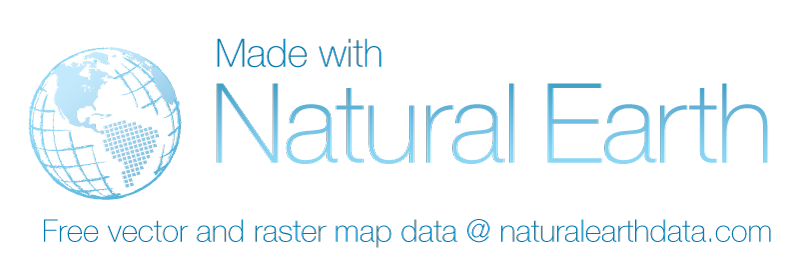

In [102]:
display(Image("../doc/img/NEV-Logo-color.png", width=500))

(Атрибуция: Made with Natural Earth. Free vector and raster map data @ naturalearthdata.com)

Из этого источника мы возьмём ряд датасетов и поделим их по группам. Используемые масштабы:
- 10m - 1:10000000, 1см = 100км;
- 50m - 1:50000000, 1см = 500км;
- 110m - 1:110000000, 1см = 1100км.

Дополнительный источник данных относится к бассейнам: ArcGIS REST Services Directory "Layer: Basins classified by sub regime CGG GeoVerse (ID:0)": https://services5.arcgis.com/33PZ8RasWNSHnkUG/ArcGIS/rest/services/Sedimentary_Basins_of_the_World/FeatureServer/0. Данные были загружены и сохранены в /data/basins.csv.

##### Гео-датасеты

In [7]:
land = gpd.read_file("../data/ne_50m_land.zip")['geometry']
land_10m = gpd.read_file("../data/ne_10m_land.zip")['geometry']
ocean_50m = gpd.read_file("../data/ne_50m_ocean.zip")['geometry']
ocean_110m = gpd.read_file("../data/ne_110m_ocean.zip")['geometry']
ne_50m_geography_marine_polys = gpd.read_file("../data/ne_50m_geography_marine_polys.zip")
lakes = gpd.read_file("../data/ne_50m_lakes.zip")['geometry']
geography_regions = gpd.read_file("../data/ne_50m_geography_regions_polys.zip")
rivers_lake_centerlines = gpd.read_file("../data/ne_50m_rivers_lake_centerlines.zip")['geometry']
major_islands = gpd.read_file("../data/ne_50m_coastline.zip")['geometry']
minor_islands = gpd.read_file("../data/ne_10m_minor_islands.zip")['geometry']

##### Формирование подмножеств геопризнаков

In [8]:
bays = ne_50m_geography_marine_polys[ne_50m_geography_marine_polys.featurecla == 'bay']['geometry']
gulfs = ne_50m_geography_marine_polys[ne_50m_geography_marine_polys.featurecla == 'gulf']['geometry']
straits = ne_50m_geography_marine_polys[ne_50m_geography_marine_polys.featurecla == 'strait']['geometry']
channels = ne_50m_geography_marine_polys[ne_50m_geography_marine_polys.featurecla == 'channel']['geometry']
sounds = ne_50m_geography_marine_polys[ne_50m_geography_marine_polys.featurecla == 'sound']['geometry']
rivers = ne_50m_geography_marine_polys[ne_50m_geography_marine_polys.featurecla == 'river']['geometry']
isthmuses = geography_regions[geography_regions.FEATURECLA == 'Isthmus']['geometry']
deltas = geography_regions[geography_regions.FEATURECLA == 'Delta']['geometry']
coasts = geography_regions[geography_regions.FEATURECLA == 'Coast']['geometry']
lake_regions = geography_regions[geography_regions.FEATURECLA == 'Lake']['geometry']
islands = geography_regions[geography_regions.FEATURECLA.isin(['Island group', 'Island'])]['geometry']

In [9]:
bunyu_coords = Point(117.833, 3.5)
bunyu_island = gpd.GeoSeries(
    [extract_polygon(land_10m[land_10m.geometry.contains(bunyu_coords)].iloc[0], bunyu_coords)],
    crs="EPSG:4326"
)

In [10]:
all_lakes = gpd.GeoDataFrame(
    geometry=pd.concat([lakes, rivers_lake_centerlines, lake_regions], ignore_index=True),
    crs="EPSG:4326").dissolve()

In [11]:
all_islands = gpd.GeoDataFrame(
    geometry=pd.concat([islands, major_islands, minor_islands, bunyu_island], ignore_index=True),
    crs="EPSG:4326").dissolve()

##### Бассейны
Onshore/offshore mapping получен из датасета ARCGIS [Sedimentary_Basins_of_the_World](https://services5.arcgis.com/33PZ8RasWNSHnkUG/ArcGIS/rest/services/Sedimentary_Basins_of_the_World/FeatureServer/0) и преобразован в [load_basins_data](load_basins_data.ipynb).

In [12]:
basins = pd.read_csv("../data/basins.csv")
basins_mapped = pd.read_csv("../data/basins_mapped.csv")

In [13]:
basins.head()

,basin_name,location
0,Faroe - Shetland Escarpment,Offshore
1,Porcupine,Offshore
2,North Lewis,Offshore
3,South Celtic Sea,Offshore
4,Blake Plateau Ultradeep,Offshore


In [14]:
basins_mapped.head()

,basin_name,location
0,amu darya,onshore
1,anadarko,onshore
2,appalachian,onshore
3,aquitaine,onshore-offshore
4,arkoma,onshore


### Ознакомление с датасетом

In [15]:
train_oil_df.head(5)

,field_name,reservoir_unit,country,region,basin_name,tectonic_regime,latitude,longitude,operator_company,onshore_offshore,hydrocarbon_type,reservoir_status,structural_setting,depth,reservoir_period,lithology,thickness_gross_average_ft,thickness_net_pay_average_ft,porosity,permeability
0,zhirnov,melekeskian,russia,former soviet union,volga-ural,compression/evaporite,51.0000,44.8042,nizhnevolzhsknet,onshore,oil,declining production,foreland,1870,carboniferous,sandstone,262.0,33.0,24.0,30.0
1,lagoa parda,lagoa parda (urucutuca),brazil,latin america,espirito santo,extension,-19.6017,-39.8332,petrobras,onshore,oil,nearly depleted,passive margin,4843,paleogene,sandstone,2133.0,72.0,23.0,350.0
2,abqaiq,arab d,saudi arabia,middle east,the gulf,compression/evaporite,26.0800,49.8100,saudi aramco,onshore,oil,rejuvenating,foreland,6050,jurassic,limestone,250.0,184.0,21.0,410.0
3,murchison,brent,uk /norway,europe,north sea northern,extension,61.3833,1.7500,cnr,offshore,oil,nearly depleted,rift,8988,jurassic,sandstone,425.0,300.0,22.0,750.0
4,west pembina,nisku (pembina l pool),canada,north america,western canada,compression,53.2287,-115.8008,numerous,onshore,oil,unknown,foreland,9306,devonian,dolomite,233.0,167.0,11.8,1407.0


**Идентификаторы месторождения**
* Field name - название месторождения
* Reservoir unit - юнит месторождения

Название и юнит месторождения, как мы убедимся, уникально идентифицируют месторождение. Кроме того, названия содержат полезную для задачи информацию. 

**Локация месторождения**
* Country - страна расположения
* Region - регион расположения
* Latitude - широта
* Longitude - долгота

Координаты являются очень важным источником сведений о месторждении. Многие признаки и анализ будут выполнены, как раз, на координатах. Страна и регион, сами по себе несут ограниченную полезность.

**Геологические характеристики**
* Basin name - название бассейна пород;
* Reservoir period - литологический период;
* Lithology (main) - литология;
* Tectonic regime - тектонический режим;
* Structural setting - структурные свойства.

Предполагается, что литология, тектоника и структурные характеристики помогут отличать береговые и оффшорные месторождения. Бассейн будем рассматривать, как агрегатор периода и других геологических признаков.

**Эксплуатационные характеристики**
* Operator company - название компании. В целом, ожидается ограниченная полезность этого показателя, т.к. под месторождения могут создаваться отдельные юрлица, чтобы ограничить ответственность и проблемы владельца одим ЮЛ, упростить получение лицензий и компартментализировать эксплуатацию основных средств. Некоторые операторы, вероятно, могут специализироваться на береговых/оффшорных месторождений. Имеет смысл проверить.
* Hydrocarbon type (main) - тип углеводорода. Признак сообщает, скорее преимущественный углеводород, который добывается на месторождении, хотя на нефтяных скважинах добывается и попутный газ. 
* Reservoir status (current) - статус месторождения. Скорее всего, признак будет бесполезен, т.к. это эксплуатационное состояние, которое, в принципе, не может сообщать о локации.
* Depth (top reservoir ft TVD) - глубина. 
* Thickness (gross average ft) - общая толщина
* Thickness (net pay average ft) - эффективная толщина
* Porosity (matrix average 20) - Permeability (air average mD) – проницаемость

Толщина и проницаемость, вероятно, могут содержать какую-то информацию о локации.

В качестве глубины указана [True Vertical Depth](https://en.wikipedia.org/wiki/True_vertical_depth) - длина воображаемой вертикальной линии от поверхности по координатам до точки интереса (`a` на иллюстрации). Т.к. месторождения классифицируются по глубинам залегания, а по координатам можно определить находится ли там вода или суша, то можно было бы построить из этих сведений хорошие признаки. Существуют датасеты с бариметрическими данными для координат (например, [GEBCO](https://www.gebco.net/data-products/gridded-bathymetry-data)), по которым можно было бы определить глубину от поверхности до дна и вычислить TVD (True Vertical Depth Sub-Sea). Но сам датасет достаточно тяжёлый, поэтому рассмотрим его использование, если нужно будет повысить точность.

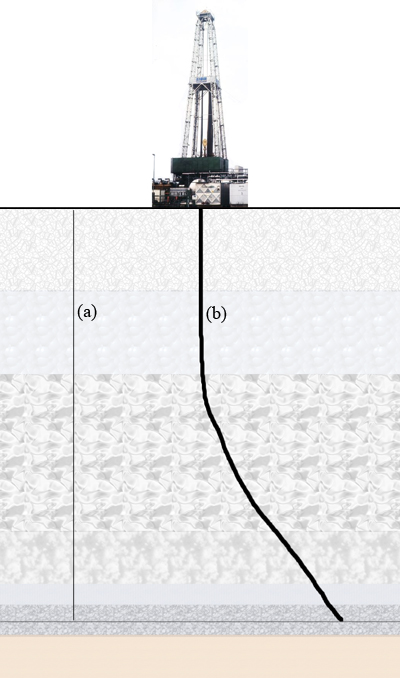

In [105]:
display(Image("../doc/img/TVD.png", width=200))

Источник: https://en.wikipedia.org/wiki/True_vertical_depth

Целевая переменная:
* Onshore or offshore - целевая переменная (ONSHORE - 1, OFFSHORE - 0, ONSHORE-OFFSHORE - 2)

Здесь важно отметить, что под береговыми ("ONSHORE") месторождениями понимаются, в том числе, и те, которые находятся в озёрах. Это мы выясним дополнительно в ходе анализа.  


### Уникальность
Уникальность задана двумя полями. Можно не включать эти поля в список признаков.

In [17]:
unique_fields = train_oil_df[['field_name', 'reservoir_unit']].duplicated(keep=False)
train_oil_df[unique_fields].sort_values(by=['field_name'])

,field_name,reservoir_unit,country,region,basin_name,tectonic_regime,latitude,longitude,operator_company,onshore_offshore,hydrocarbon_type,reservoir_status,structural_setting,depth,reservoir_period,lithology,thickness_gross_average_ft,thickness_net_pay_average_ft,porosity,permeability


### Пропущенные значения

In [18]:
missing_val_cnts = train_oil_df.isna().sum()
missing_val_cnts[missing_val_cnts > 0]

country       27
region        38
basin_name    38
latitude      27
longitude     30
dtype: int64

Заметим:
- В колонках определяющих уникальность, пропусков нет. Значит другие значения можно заполнить по этим колонкам.
- Количество отсутствующих значений для региона и названия бассейна одинаковое. Проверим, что значения отсутствуют в одних и тех же записях.

In [19]:
(train_oil_df['region'].isna() & train_oil_df['basin_name'].isna()).sum()

np.int64(38)

Заполним регион и страну значением 'unknown'. Бассейны рассмотрим вместе с координатами.

In [20]:
train_oil_df['region'] = train_oil_df['region'].fillna('unknown')
train_oil_df['country'] = train_oil_df['country'].fillna('unknown')

Посмотрим, как отсутствуют координаты.

In [21]:
missing_lat = train_oil_df['latitude'].isna()
missing_lon = train_oil_df['longitude'].isna()

In [22]:
missing_coords_by_field = train_oil_df[missing_lat | missing_lon][
    ['field_name', 'reservoir_unit', 'country']]
missing_coords_by_field

,field_name,reservoir_unit,country
11,badr el din-2,bahariya,unknown
12,bridger lake,dakota sandstone (lower member),unknown
15,scott,sgiath-piper,unknown
28,zakum,thamama zone ii,unknown
33,gasikule,upper ganchaigou-lower youshas,unknown
35,uzen,units xiii-xviii,unknown
37,ula,ula,unknown
49,yibal,khuff,unknown
50,palm valley,pacoota and stairway,unknown
55,wubaiti,huanglong,unknown


Важно отметить, что названия и юниты месторождения нам даны даже там, где координат нет, а значит, можно восстановить их.

In [23]:
test_oil_df.isna().sum()

field_name                       0
reservoir_unit                   0
country                         13
region                          16
basin_name                       8
tectonic_regime                  0
latitude                        13
longitude                       16
operator_company                 0
hydrocarbon_type                 0
reservoir_status                 0
structural_setting               0
depth                            0
reservoir_period                 0
lithology                        0
thickness_gross_average_ft       0
thickness_net_pay_average_ft     0
porosity                         0
permeability                     0
dtype: int64

### Заполнение пропущенных координат

Т.к. названия и юниты месторождений нам даны и их всего 30, я решил их восстановить. Геомэппинг по названиям не дал надёжных результатов. Пришлось искать через поисковые системы. Оказалось, что задача непростая, т.к. для некоторых месторождений сведеий почти нет (Yakin Complex, например, находится в районе, который не указан в датасете), а месторождения в США имеют свою систему поиска.

In [26]:
missing_coordinates = pd.read_csv("../data/train_missing_coordinates.csv")
missing_coordinates = missing_coordinates.fillna("")
display(HTML(missing_coordinates.to_html()))

,field_name,reservoir_unit,latitude,longitude,source,comment
0,badr el din-2,bahariya,29.9247,27.9233,"https://www.gem.wiki/Bed-2_Oil_and_Gas_Field_(Egypt)\r\nhttps://www.google.com/maps?ll=29.924657,27.923297&z=8&t=m&hl=en&gl=US&mapclient=apiv3",
1,bridger lake,dakota sandstone (lower member),40.9675,-110.3182,https://www.geonames.org/5771952/bridger-lake-oil-field.html,
2,scott,sgiath-piper,58.2800,0.1200,https://en.wikipedia.org/wiki/Piper_oilfield,
3,zakum,thamama zone ii,24.8429,53.6563,https://www.gem.wiki/Upper_Zakum_Oil_Field_(United_Arab_Emirates),
4,gasikule,upper ganchaigou-lower youshas,38.1465,90.9065,"https://www.gem.wiki/Gasikule_Oil_Field_(Qinghai,_China)",
5,uzen,units xiii-xviii,43.4175,52.8658,https://www.gem.wiki/Uzen_Oil_and_Gas_Field_(Kazakhstan),
6,ula,ula,57.1114,2.8473,https://en.wikipedia.org/wiki/Ula_oil_field,
7,yibal,khuff,22.1322,55.9842,https://www.gem.wiki/Yibal_Oil_and_Gas_Field_(Oman),
8,palm valley,pacoota and stairway,-24.0667,132.8167,https://grokipedia.com/page/palm_valley_northern_territory,
9,wubaiti,huanglong,31.3593,108.5218,"https://www.gem.wiki/Wubaiti_Gas_Field_(Chongqing,_China)",


In [27]:
train_oil_df_filled = train_oil_df.merge(
    missing_coordinates[["field_name", "reservoir_unit", "latitude", "longitude"]],
    on=["field_name", "reservoir_unit"],
    how='left', suffixes=('', '_fill'))
train_oil_df_filled['latitude'] = train_oil_df_filled['latitude'].fillna(train_oil_df_filled['latitude_fill'])
train_oil_df_filled['longitude'] = train_oil_df_filled['longitude'].fillna(train_oil_df_filled['longitude_fill'])
train_oil_df_filled.drop(columns=['latitude_fill', 'longitude_fill'], inplace=True)
train_oil_df_filled[['latitude', 'longitude']].isna().sum()

latitude     0
longitude    0
dtype: int64

### Заполнение бассейнов
Т.к. названия и юниты месторождений нам даны и их всего 38, я аналогично решил восстановить. Пользовался теми же источниками, что и для координат, где названия бассейновы были доступны, где не было таких сведений, пользовался DeepSeek'ом. Сверялся с [Sedimentary_Basins_of_the_World](https://services5.arcgis.com/33PZ8RasWNSHnkUG/ArcGIS/rest/services/Sedimentary_Basins_of_the_World/FeatureServer/0).

In [28]:
missing_basins = pd.read_csv("../data/missing_basins.csv")

In [29]:
train_oil_df_filled = train_oil_df_filled.merge(missing_basins[["basin_name", "field_name", "reservoir_unit"]],
                                                on=["field_name", "reservoir_unit"],
                                                how='left', suffixes=('', '_fill'))
train_oil_df_filled['basin_name'] = train_oil_df_filled['basin_name'].fillna(train_oil_df_filled['basin_name_fill'])
train_oil_df_filled.drop(columns=['basin_name_fill'], inplace=True)
train_oil_df_filled[['basin_name']].isna().sum()

basin_name    0
dtype: int64

### Соотношение классов

In [30]:
train_oil_df['onshore_offshore'].value_counts()

onshore_offshore
onshore             218
offshore             86
onshore-offshore      5
Name: count, dtype: int64

Больше всего в датасете береговых месторождений, присутствует лишь 5 смешанных.

### Совместное использование бассейнов странами

In [31]:
basin_country_shared = train_oil_df.groupby('basin_name', as_index=False)['country'].unique()
basin_country_shared['shared_by'] = basin_country_shared['country'].apply(lambda x: len(x))
basin_country_shared = basin_country_shared[basin_country_shared['shared_by'] > 1].sort_values(by='shared_by',
                                                                                               ascending=False)
basin_country_shared

,basin_name,country,shared_by
51,north sea northern,"[uk /norway, norway, uk, norway /uk]",4
1,amu darya,"[uzbekistan, turkmenistan, afghanistan]",3
81,the gulf,"[saudi arabia, neutral zone, qatar]",3
50,north sea central,"[uk, norway, denmark]",3
19,eastern venezuela,"[venezuela, trinidad and tobago]",2
47,niger delta,"[equatorial guinea, nigeria]",2
27,ghadames,"[algeria, tunisia /algeria]",2
65,rub al khali,"[uae, qatar]",2
90,williston,"[usa, canada]",2
92,zagros,"[iran, iraq]",2


Важно отметить следующее:
- Есть бассейны, которые используются несколькими странами;
- есть дубликаты вида uk/norway, norway/uk, а значит можно их унифицировать и расширить обучающую выборку;

In [32]:
uk_nor = train_oil_df['country'] == 'uk /norway'
nor_uk = train_oil_df['country'] == 'norway /uk'

train_oil_df[uk_nor | nor_uk][
    ['field_name', 'reservoir_unit', 'basin_name', 'country', 'operator_company', 'latitude', 'longitude',
     'onshore_offshore']]

,field_name,reservoir_unit,basin_name,country,operator_company,latitude,longitude,onshore_offshore
3,murchison,brent,north sea northern,uk /norway,cnr,61.3833,1.7500,offshore
295,statfjord,brent,north sea northern,norway /uk,statoilhydro,61.2042,1.8287,offshore


Заменим разные названия.

In [33]:
train_oil_df.loc[nor_uk, 'country'] = 'uk /norway'

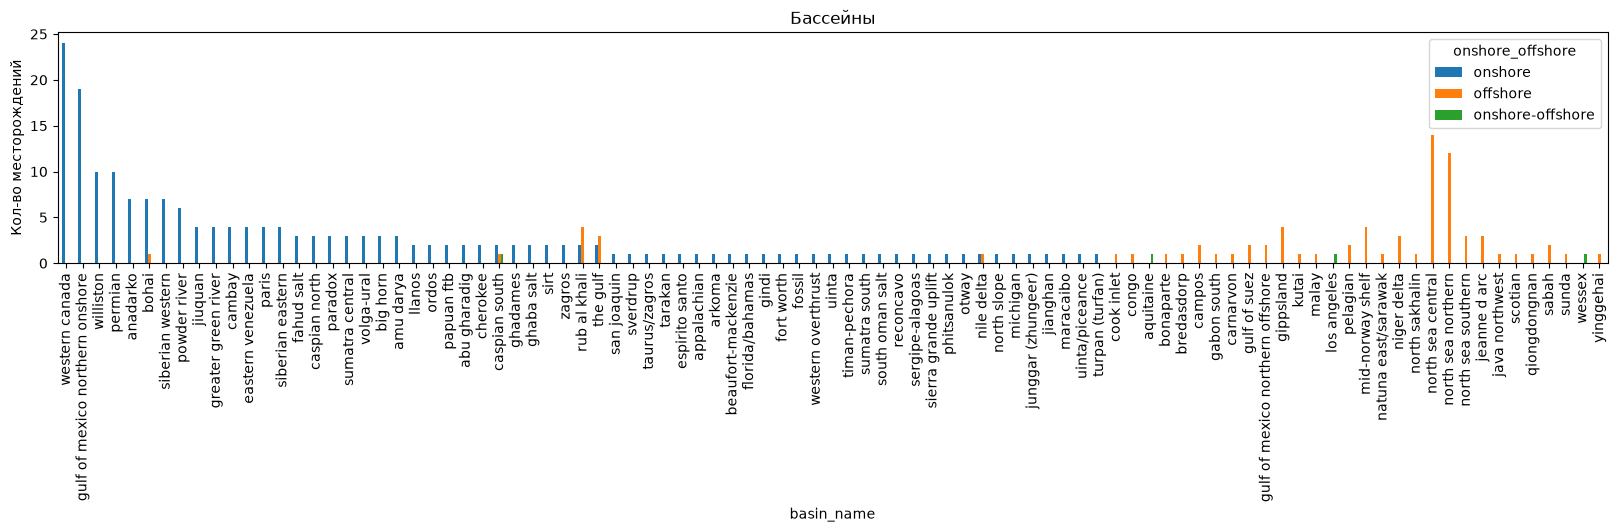

In [34]:
plot_ct(train_oil_df, 'basin_name', 'Бассейны', figsize=(20, 3))

Локации месторождений достаточно хорошо разделены по бассейнам.

### Геоанализ

In [35]:
gdf = gpd.GeoDataFrame(
    train_oil_df_filled,
    geometry=gpd.points_from_xy(train_oil_df_filled.longitude, train_oil_df_filled.latitude),
    crs="EPSG:4326"
)

#### Расположение месторождений

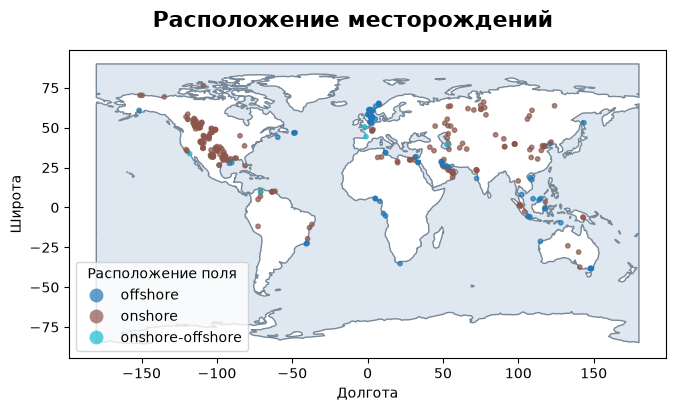

In [36]:
fig, ax = plt.subplots(figsize=(12, 4))
ocean_110m.plot(ax=ax, **water_col)
gdf.plot(ax=ax, column='onshore_offshore', **field_markers, **field_lgnd)
ax.set_ylabel('Широта')
ax.set_xlabel('Долгота')
ax.grid(False)
fig.suptitle('Расположение месторождений', fontsize=16, fontweight='bold')
plt.show()

#### Подбор масштабов
Для корректных расчётов подходит масштаб карт 1:50000000.

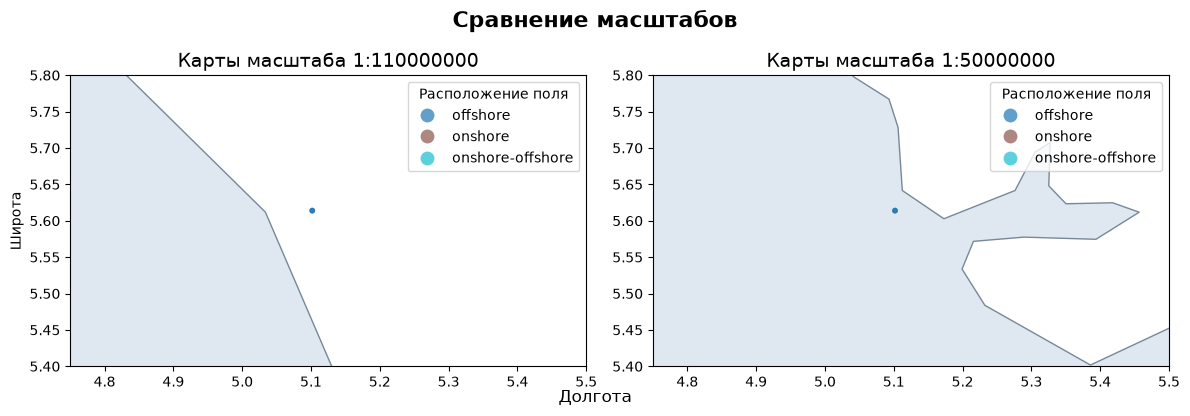

In [37]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ocean_110m.plot(ax=ax1, **water_col)
gdf.plot(ax=ax1, column='onshore_offshore', **field_markers, **field_lgnd)
ocean_50m.plot(ax=ax2, **water_col)
gdf.plot(ax=ax2, column='onshore_offshore', **field_markers, **field_lgnd)
ax1.set_ylim(5.4, 5.8)
ax1.set_xlim(4.75, 5.5)
ax2.set_ylim(5.4, 5.8)
ax2.set_xlim(4.75, 5.5)
ax1.set_title('Карты масштаба 1:110000000', fontsize=14)
ax2.set_title('Карты масштаба 1:50000000', fontsize=14)
ax1.set_ylabel('Широта')
fig.text(0.5, 0.0, 'Долгота', ha='center', fontsize=12)
fig.suptitle('Сравнение масштабов', fontsize=16, fontweight='bold', y=.98)
plt.tight_layout()
plt.show()

Масштаб карт 1:110000000 не позволяет корректно вычислить находится ли месторождение в воде или на суше, а масштаб 1:50000000 - позволяет.

#### Анализ расположения: суша или вода

In [38]:
gdf['water_pct'] = gdf.apply(lambda row: water_fraction(point_lat=row.latitude,
                                                        point_lon=row.longitude,
                                                        water_shapes=ocean_50m,
                                                        radius_km=2), axis=1)

In [39]:
gdf.groupby(['onshore_offshore', 'water_pct']).size().reset_index(name='count')

,onshore_offshore,water_pct,count
0,offshore,0.0000,1
1,offshore,1.0000,85
2,onshore,0.0000,216
3,onshore,0.9894,1
4,onshore,1.0000,1
5,onshore-offshore,0.0000,3
6,onshore-offshore,0.1127,1
7,onshore-offshore,1.0000,1


##### Признаки расположения координат на суше и в воде 
Достаточно одного признака: `is_in_water`.

In [40]:
gdf['is_in_water'] = gdf.apply(lambda row: within_shape(lat=row.latitude, lon=row.longitude, gdf=ocean_50m), axis=1)
gdf.groupby(['onshore_offshore', 'is_in_water']).size().reset_index(name='count')

,onshore_offshore,is_in_water,count
0,offshore,False,1
1,offshore,True,85
2,onshore,False,216
3,onshore,True,2
4,onshore-offshore,False,4
5,onshore-offshore,True,1


##### Оффшорные месторождения на суше

In [41]:
offshore_outlier = (gdf['onshore_offshore'] == 'offshore') & (gdf['water_pct'] == 0)

In [42]:
gdf[offshore_outlier][['field_name', 'reservoir_unit', 'latitude', 'longitude', 'onshore_offshore']]

,field_name,reservoir_unit,latitude,longitude,onshore_offshore
292,berri,hanifa,26.9833,49.6167,offshore


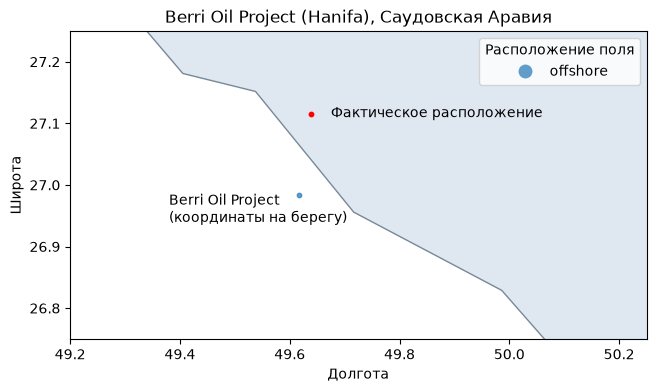

In [43]:
fig, ax = plt.subplots(figsize=(12, 4))
ocean_50m.plot(ax=ax, **water_col)
gdf[offshore_outlier].plot(ax=ax, column='onshore_offshore', **field_markers, **field_lgnd)
ax.annotate('Berri Oil Project\n(координаты на берегу)', xy=(49.6167, 26.9833), xytext=(49.38, 26.940), fontsize=10)
ax.scatter(49.6389, 27.1145, color='red', s=10)
ax.annotate('Фактическое расположение', xy=(49.6389, 27.11), xytext=(49.675, 27.11), fontsize=10)
ax.set_ylim(26.75, 27.25)
ax.set_xlim(49.2, 50.25)
ax.set_ylabel('Широта')
ax.set_xlabel('Долгота')
ax.set_title('Berri Oil Project (Hanifa), Саудовская Аравия')
plt.show()

Месторождение Berri Oil Project (Hanifa) в датасете указано, как оффшорное. Согласно информации https://www.gem.wiki/Berri_Oil_Project_(Saudi_Arabia), это месторождение действительно является оффшорным, но имеет другие координаты в море: 27.1145, 49.6389. Присвоим этому месторождению координаты из справочника и пересчитаем `water_pct`.

In [44]:
berri_hanifa_coords = (27.11, 49.6389)
berri_hanifa_idx = (gdf["field_name"] == "berri") & (gdf["reservoir_unit"] == "hanifa")
gdf.loc[berri_hanifa_idx, 'latitude'] = berri_hanifa_coords[0]
gdf.loc[berri_hanifa_idx, 'longitude'] = berri_hanifa_coords[1]
gdf.loc[berri_hanifa_idx, 'water_pct'] = water_fraction(point_lat=berri_hanifa_coords[0],
                                                        point_lon=berri_hanifa_coords[1],
                                                        water_shapes=ocean_50m,
                                                        radius_km=2)

In [45]:
gdf[offshore_outlier][['field_name', 'reservoir_unit', 'latitude', 'longitude', 'onshore_offshore', 'water_pct']]

,field_name,reservoir_unit,latitude,longitude,onshore_offshore,water_pct
292,berri,hanifa,27.11,49.6389,offshore,1.0


In [46]:
gdf.groupby(['onshore_offshore', 'water_pct']).size().reset_index(name='count')

,onshore_offshore,water_pct,count
0,offshore,1.0000,86
1,onshore,0.0000,216
2,onshore,0.9894,1
3,onshore,1.0000,1
4,onshore-offshore,0.0000,3
5,onshore-offshore,0.1127,1
6,onshore-offshore,1.0000,1


##### Береговые месторождения, окружённые водой

In [47]:
onshore_outliers = (gdf['onshore_offshore'] == 'onshore') & (gdf['water_pct'] > 0.9)

In [48]:
gdf[onshore_outliers]

,field_name,reservoir_unit,country,region,basin_name,tectonic_regime,latitude,longitude,operator_company,onshore_offshore,...,depth,reservoir_period,lithology,thickness_gross_average_ft,thickness_net_pay_average_ft,porosity,permeability,geometry,water_pct,is_in_water
109,north sabine lake,lower hackberry (frio),usa,north america,gulf of mexico northern onshore,gravity/extension/evaporite/synsedimentation,29.9587,-93.7991,hillcorp energy,onshore,...,10940,paleogene,shaly sandstone,265.0,130.0,26.0,425.0,POINT (-93.7991 29.9587),0.9894,True
298,bunyu,tarakan-santul-tabul-bunyu,indonesia,far east,tarakan,inversion/compression/extension/shale,3.4708,117.8625,pertamina,onshore,...,1115,neogene,thinly-bedded sandstone,8200.0,390.0,25.0,1000.0,POINT (117.8625 3.4708),1.0000,True


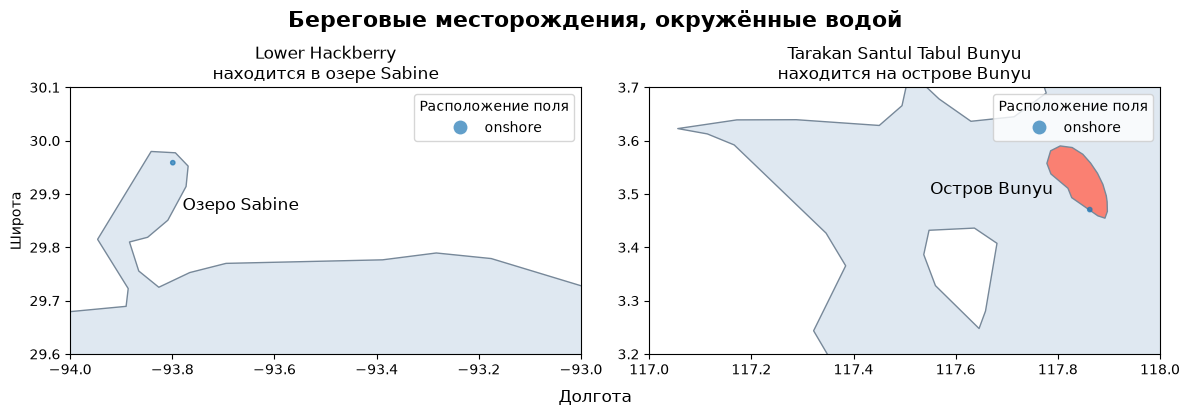

In [49]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ocean_50m.plot(ax=ax1, **water_col)
gdf[onshore_outliers].plot(ax=ax1, column='onshore_offshore', **field_markers, **field_lgnd)
ax1.annotate('Озеро Sabine', xy=(-93.9034, 29.8222), xytext=(-93.78, 29.87),
             fontsize=12, zorder=10)
ax1.set_ylim(29.6, 30.1)
ax1.set_xlim(-94, -93.0)
ax1.set_title('Lower Hackberry\nнаходится в озере Sabine')

ocean_50m.plot(ax=ax2, **water_col)
bunyu_island.plot(ax=ax2, color='salmon', edgecolor='lightslategrey')
gdf[onshore_outliers].plot(ax=ax2, column='onshore_offshore', **field_markers, **field_lgnd)
ax2.annotate('Остров Bunyu', xy=(117.833, 3.5), xytext=(117.55, 3.5), fontsize=12)
ax2.set_ylim(3.2, 3.7)
ax2.set_xlim(117.0, 118)
ax2.set_title('Tarakan Santul Tabul Bunyu\nнаходится на острове Bunyu')
ax1.set_ylabel('Широта')
fig.text(0.5, 0.0, 'Долгота', ha='center', fontsize=12)
fig.suptitle('Береговые месторождения, окружённые водой', fontsize=16, fontweight='bold', y=.98)
plt.tight_layout()
plt.show()

Для таких месторождений следует добавить признаки, указывающие на то, что они находятся в озере или на острове.

In [50]:
gdf['is_on_island'] = gdf.apply(lambda row: within_shape(lat=row.latitude, lon=row.longitude, gdf=all_islands), axis=1)
gdf['is_in_gulf'] = gdf.apply(lambda row: within_shape(lat=row.latitude, lon=row.longitude, gdf=gulfs), axis=1)
gdf['is_in_strait'] = gdf.apply(lambda row: within_shape(lat=row.latitude, lon=row.longitude, gdf=straits), axis=1)
gdf['is_in_delta'] = gdf.apply(lambda row: within_shape(lat=row.latitude, lon=row.longitude, gdf=deltas), axis=1)
gdf['is_in_bay'] = gdf.apply(lambda row: within_shape(lat=row.latitude, lon=row.longitude, gdf=bays), axis=1)

gdf['is_in_lake'] = gdf.apply(lambda row: within_shape(lat=row.latitude, lon=row.longitude, gdf=all_lakes), axis=1)
gdf['is_in_channel'] = gdf.apply(lambda row: within_shape(lat=row.latitude, lon=row.longitude, gdf=channels), axis=1)
gdf['is_in_sound'] = gdf.apply(lambda row: within_shape(lat=row.latitude, lon=row.longitude, gdf=sounds), axis=1)
gdf['is_in_river'] = gdf.apply(lambda row: within_shape(lat=row.latitude, lon=row.longitude, gdf=rivers), axis=1)
gdf['is_on_isthmus'] = gdf.apply(lambda row: within_shape(lat=row.latitude, lon=row.longitude, gdf=isthmuses), axis=1)
gdf['is_on_coast'] = gdf.apply(lambda row: within_shape(lat=row.latitude, lon=row.longitude, gdf=coasts), axis=1)

Месторождение в озере Sabine отмечено как залив. На странице [Sabine Lake в Wikipedia](https://en.wikipedia.org/wiki/Sabine_Lake) пишут:
> Sabine Lake is a bay on the Gulf coasts of Texas and Louisiana, located approximately 90 miles (140 km) east of Houston and 160 miles (260 km) west of Baton Rouge, adjoining the city of Port Arthur. The lake is formed by the confluence of the Neches and Sabine Rivers and connects to the Gulf of Mexico through Sabine Pass.

По сути, озеро соединено с Мексиканским заливом. Как признак, это тоже подходит, но можно посмотреть ещё упоминания озёр в названиях.

In [51]:
names_concat = gdf['field_name'] + gdf['reservoir_unit'] + gdf['basin_name']

In [52]:
print(f"Упоминаний озёр: {names_concat.str.contains("lake").sum()}")

Упоминаний озёр: 4


In [53]:
gdf['ref_lake'] = names_concat.str.contains("lake")

In [54]:
gdf[onshore_outliers][['field_name', 'latitude', 'longitude', 'is_on_island', 'is_in_gulf', 'ref_lake']]

,field_name,latitude,longitude,is_on_island,is_in_gulf,ref_lake
109,north sabine lake,29.9587,-93.7991,False,True,True
298,bunyu,3.4708,117.8625,True,False,False


Посмотрим на разметку новых признаков. Имеют вхождения только признаки для осторовов, заливов, проливов, дельт рек и бухт. Остальные признаки вхождений не имеют.

In [55]:
geo_features = ['is_on_island', 'is_in_lake', 'is_in_bay', 'is_in_gulf', 'is_in_strait', 'is_in_channel', 'is_in_sound',
                'is_in_river', 'is_on_isthmus', 'is_in_delta', 'is_on_coast']
geo_feature_counts = gdf[geo_features].sum()
available_geo_features = geo_feature_counts[geo_feature_counts > 0]
available_geo_features

is_on_island    17
is_in_bay        1
is_in_gulf      13
is_in_strait     2
is_in_delta      1
dtype: int64

##### Месторождения со смешанными значениями

In [56]:
mixed_on_offshores = gdf['onshore_offshore'] == 'onshore-offshore'

In [57]:
gdf[mixed_on_offshores][
    ['field_name', 'reservoir_unit', 'basin_name', 'latitude', 'longitude', 'water_pct', 'is_on_island', 'is_in_gulf',
     'is_in_strait',
     'is_in_delta', 'is_in_bay']]

,field_name,reservoir_unit,basin_name,latitude,longitude,water_pct,is_on_island,is_in_gulf,is_in_strait,is_in_delta,is_in_bay
64,wytch farm,sherwood,wessex,50.6672,-2.0278,0.0000,True,False,False,False,False
92,tia juana,la rosa-lagunillas (tia juana onshore area),maracaibo,9.8179,-71.0365,0.0000,False,False,False,False,False
134,cheleken,red series,caspian south,39.5800,53.1300,1.0000,False,False,False,False,False
185,parentis,unnamed,aquitaine,44.3367,-1.0959,0.0000,False,False,False,False,False
220,huntington beach,jones zone,los angeles,33.6998,-118.0335,0.1127,False,False,False,False,False


###### Wytch Farm
Wytch Farm находится в южном побережье Соединённого Королевства. Есть корректная отметка о том, что месторождение находится на острове. Остальные месторождения не имеют вхождений по заданным признакам.

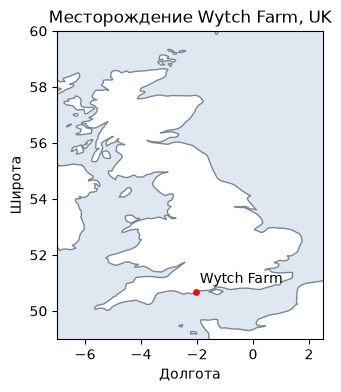

In [58]:
fig, ax = plt.subplots(figsize=(12, 4))
ocean_50m.plot(ax=ax, **water_col)

ax.scatter(-2.0278, 50.6672, color='red', s=15)
ax.annotate('Wytch Farm', xy=(-2.0278, 50.6672), xytext=(-1.9, 51.0), fontsize=10)

ax.set_ylim(49, 60)
ax.set_xlim(-7, 2.5)
ax.set_ylabel('Широта')
ax.set_xlabel('Долгота')
ax.set_title('Месторождение Wytch Farm, UK')
plt.show()

##### Tia Juana
Месторождения Tía Juana на ходятся в бассейне Маракайбо.

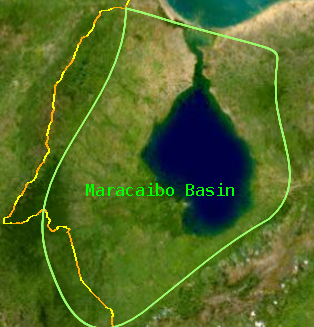

In [106]:
display(Image("../doc/img/Maracaibo_Basin.png", width=300))

Т.к. для этой записи пришлось восстанавливать координаты, стоит отметить, что в справочниках [Tía Juana Oil Field](https://www.gem.wiki/T%C3%ADa_Juana_Oil_Field_(Venezuela)) - это часть проекта "Bolivar Coastal Fields", который включает месторождения:
- Ambrosio Oil and Gas Field
- [Bachaquero Oil Field](https://www.gem.wiki/Bachaquero_Oil_Field_(Venezuela))
- [Barúa Oil Field](https://www.gem.wiki/Bar%C3%BAa_Oil_Field_(Venezuela))
- [Lagunillas Oil Field](https://www.gem.wiki/Lagunillas_Oil_Field_(Venezuela)).

Нас же интересует [Lagunillas Oil Field](https://www.gem.wiki/Lagunillas_Oil_Field_(Venezuela)), т.к. в reservoir unit есть уточнение, что это onshore. Но, что не менее важно, в тексте встерчаются упомнинания onshore/offshore, поэтому можно добавить 2 признака. 

Источники:
- [Tía Juana Oil Field](https://www.gem.wiki/T%C3%ADa_Juana_Oil_Field_(Venezuela))
- https://en.wikipedia.org/wiki/Bolivar_Coastal_Fields

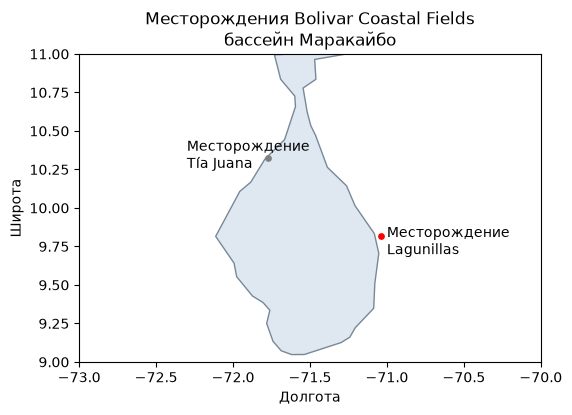

In [59]:
fig, ax = plt.subplots(figsize=(12, 4))
ocean_50m.plot(ax=ax, **water_col)

ax.scatter(-71.0365, 9.8179, color='red', s=15)
ax.annotate('Месторождение\nLagunillas', xy=(-71.0365, 9.8179), xytext=(-71.0, 9.7), fontsize=10)

ax.scatter(-71.7711, 10.3212, color='grey', s=15)
ax.annotate('Месторождение\nTía Juana', xy=(-71.7711, 10.3212), xytext=(-72.3, 10.26), fontsize=10)

ax.set_ylim(9, 11)
ax.set_xlim(-73, -70)
ax.set_ylabel('Широта')
ax.set_xlabel('Долгота')
ax.set_title('Месторождения Bolivar Coastal Fields\nбассейн Маракайбо')
plt.show()

**Cheleken**
Месторождение Челекен находится в восточной части Каспийского моря в окрестностях залива Туркменбаши. Месторождение промаркировано onshore/offshore, т.к. оно расположено частично под сушей и частично под морем.

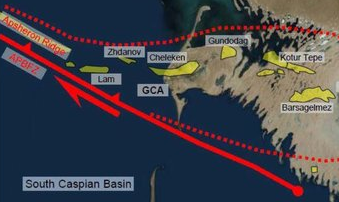

In [107]:
display(Image("../doc/img/Cheleken.png", width=400))

Источник: https://www.researchgate.net/figure/Overview-map-of-the-study-area-along-the-eastern-coast-of-the-Caspian-Sea-Turkmenistan_fig1_328854399

Можно по внешним источникам извлечь сведения о бассейне/месторождении.

In [60]:
cheleken_idx = gdf['field_name'] == 'cheleken'
gdf[cheleken_idx][['field_name', 'reservoir_unit', 'basin_name', 'water_pct', 'onshore_offshore', 'hydrocarbon_type']]

,field_name,reservoir_unit,basin_name,water_pct,onshore_offshore,hydrocarbon_type
134,cheleken,red series,caspian south,1.0,onshore-offshore,oil


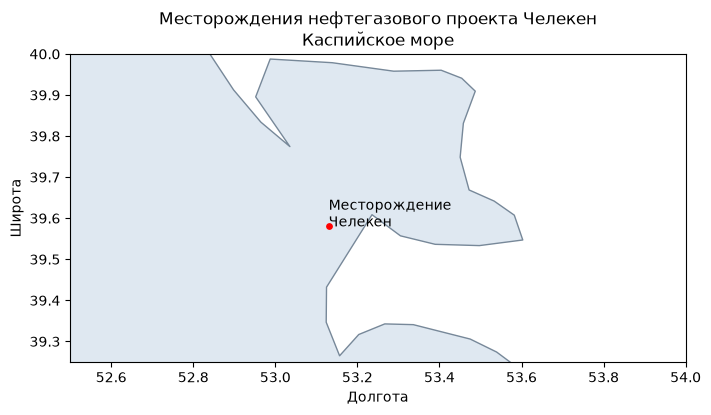

In [61]:
fig, ax = plt.subplots(figsize=(12, 4))
ocean_50m.plot(ax=ax, **water_col)

ax.scatter(53.1300, 39.5800, color='red', s=15)
ax.annotate('Месторождение\nЧелекен', xy=(53.1300, 39.5800), xytext=(53.1300, 39.5800), fontsize=10)

ax.set_ylim(39.25, 40)
ax.set_xlim(52.5, 54)
ax.set_ylabel('Широта')
ax.set_xlabel('Долгота')
ax.set_title('Месторождения нефтегазового проекта Челекен\nКаспийское море')
plt.show()

**Parentis**
Месторождение Parentis относится к Аквитанскому бассейну в Бискайском заливе. Согласно внешним классификаторам, Аквитанский бассейн является смешанным в смысле onshore/offshore.  

Сами координаты указывают на берег. Возможно, в Field Name имеется в виду не само месторождение Parentis, а провинция (Parentis province), которая действительно залегает под материком и заливом. А само месторождение Parentis находится на берегу. Возможно, придётся корректировать лейбл.

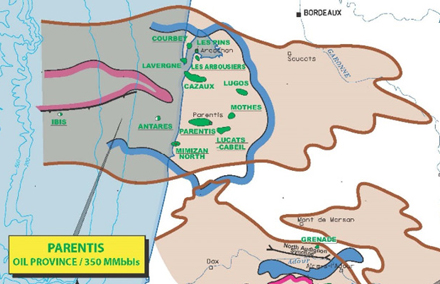

In [108]:
display(Image("../doc/img/Parentis.png", width=400))

Источник: https://www.aapg.org/news-and-media/explorer/exploration-adventures-in-frances-aquitaine-basin/

Можно по внешним источникам извлечь сведения о бассейне. 

In [62]:
parentis_idx = gdf['field_name'] == 'parentis'
gdf[parentis_idx][['field_name', 'reservoir_unit', 'basin_name', 'water_pct', 'onshore_offshore', 'hydrocarbon_type']]

,field_name,reservoir_unit,basin_name,water_pct,onshore_offshore,hydrocarbon_type
185,parentis,unnamed,aquitaine,0.0,onshore-offshore,oil


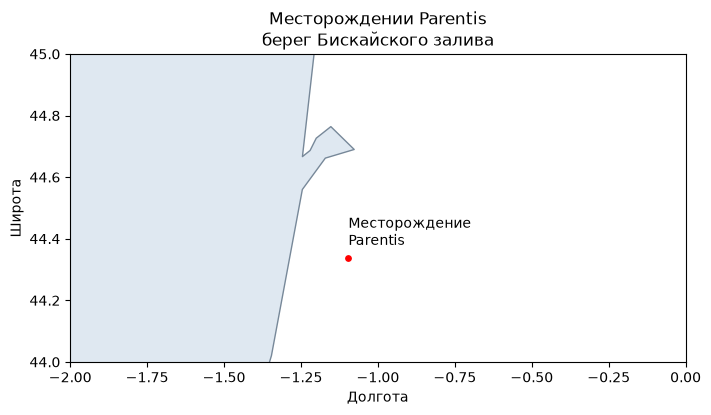

In [63]:
fig, ax = plt.subplots(figsize=(12, 4))
ocean_50m.plot(ax=ax, **water_col)

ax.scatter(-1.0959, 44.3367, color='red', s=15)
ax.annotate('Месторождение\nParentis', xy=(-1.0959, 44.3367), xytext=(-1.0959, 44.38), fontsize=10)

ax.set_ylim(44, 45)
ax.set_xlim(-2, 0)
ax.set_ylabel('Широта')
ax.set_xlabel('Долгота')
ax.set_title('Месторождении Parentis\nберег Бискайского залива')
plt.show()

##### Huntington Beach
Координаты указывают на берег, хотя само месторождение Huntington Beach находится между сушей и океаном.

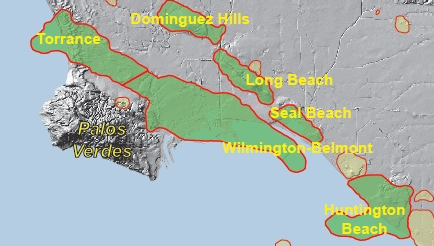

In [109]:
display(Image("../doc/img/LA_Basin.png", width=400))

Источник: https://en.wikipedia.org/wiki/Huntington_Beach_Oil_Field

Можно по внешним источникам извлечь сведения о бассейне.

In [64]:
huntington_beach_idx = gdf['field_name'] == 'huntington beach'
gdf[huntington_beach_idx][
    ['field_name', 'reservoir_unit', 'basin_name', 'water_pct', 'onshore_offshore', 'hydrocarbon_type']]

,field_name,reservoir_unit,basin_name,water_pct,onshore_offshore,hydrocarbon_type
220,huntington beach,jones zone,los angeles,0.1127,onshore-offshore,oil


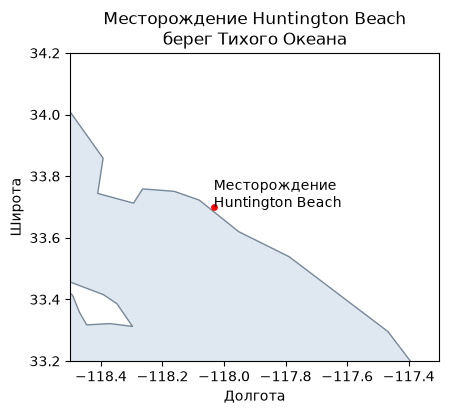

In [65]:
fig, ax = plt.subplots(figsize=(12, 4))
ocean_50m.plot(ax=ax, **water_col)

ax.scatter(-118.0335, 33.6998, color='red', s=15)
ax.annotate('Месторождение\nHuntington Beach', xy=(-118.0335, 33.6998), xytext=(-118.0335, 33.6998), fontsize=10)

ax.set_ylim(33.2, 34.2)
ax.set_xlim(-118.5, -117.3)
ax.set_ylabel('Широта')
ax.set_xlabel('Долгота')
ax.set_title('Месторождение Huntington Beach\nберег Тихого Океана')
plt.show()

##### Признаки на основе упоминаний onshore/offshore

In [66]:
print(f"Упоминаний onshore: {names_concat.str.contains("onshore").sum()}")
print(f"Упоминаний offshore: {names_concat.str.contains("offshore").sum()}")

Упоминаний onshore: 20
Упоминаний offshore: 3


In [67]:
gdf['ref_onshore'] = names_concat.str.contains('onshore')
gdf['ref_offshore'] = names_concat.str.contains('offshore')

In [68]:
gdf.groupby(['onshore_offshore', 'ref_onshore', 'ref_offshore']).size().reset_index(name='count')

,onshore_offshore,ref_onshore,ref_offshore,count
0,offshore,False,False,83
1,offshore,False,True,3
2,onshore,False,False,199
3,onshore,True,False,19
4,onshore-offshore,False,False,4
5,onshore-offshore,True,False,1


Здесь важно: 
- нет `offshore` с упоминаниями `onshore`;
- нет `onshore` с упоминаниями `offshore`;
- есть `onshore-offshore` запись с упоминанием `onshore`.

Получилось промаркировать месторождение Tia Juana признаком, который может помочь определению локации.

In [69]:
gdf[mixed_on_offshores][
    ['field_name', 'reservoir_unit', 'basin_name', 'ref_onshore']]

,field_name,reservoir_unit,basin_name,ref_onshore
64,wytch farm,sherwood,wessex,False
92,tia juana,la rosa-lagunillas (tia juana onshore area),maracaibo,True
134,cheleken,red series,caspian south,False
185,parentis,unnamed,aquitaine,False
220,huntington beach,jones zone,los angeles,False


##### Признаки на основе обучающих данных о бассейне

In [70]:
basin_location = pd.crosstab(gdf['basin_name'], gdf['onshore_offshore']).drop('unknown', errors='ignore').reset_index()

loc_mask = ((basin_location['onshore'] > 0) &
            (basin_location['offshore'] > 0))

basin_location.loc[loc_mask, 'onshore-offshore-calc'] = (
        basin_location.loc[loc_mask, 'onshore'] +
        basin_location.loc[loc_mask, 'offshore'] +
        basin_location.loc[loc_mask, 'onshore-offshore'])

basin_location['onshore-offshore-calc'] = basin_location['onshore-offshore-calc'].fillna(0).astype(int)

loc_mask_2 = ((basin_location['onshore'] == 0) &
              (basin_location['offshore'] == 0) &
              (basin_location['onshore-offshore'] > 0))

basin_location.loc[loc_mask_2, 'onshore-offshore-calc'] = basin_location.loc[loc_mask_2, 'onshore-offshore']

In [71]:
inferred_location_map = construct_basin_location_mapper(basin_location)

In [72]:
gdf['basin_location'] = gdf['basin_name'].map(inferred_location_map).fillna("unknown")

In [73]:
gdf.groupby(['onshore_offshore', 'basin_location']).size().reset_index(name='count')

,onshore_offshore,basin_location,count
0,offshore,offshore,75
1,offshore,onshore-offshore,11
2,onshore,onshore,204
3,onshore,onshore-offshore,14
4,onshore-offshore,onshore,1
5,onshore-offshore,onshore-offshore,4


##### Признаки на основе внешних данных о бассейне
Рассмотрим данные о бассейне, которые мы загрузили в ноутбуке [load_basins_data](load_basins_data.ipynb).

In [74]:
basins_mapped = pd.read_csv("../data/basins_mapped.csv")
basins_mapped = basins_mapped.drop(basins_mapped[basins_mapped['basin_name'] == 'unknown'].index).reset_index(
    drop=True).to_dict("records")
external_location_map = {b['basin_name']: b['location'] for b in basins_mapped}

In [75]:
basin_location_map_combined = construct_basin_location_mapper_with_external(basin_location, external_location_map)

In [76]:
gdf['basin_location_ext'] = gdf['basin_name'].map(basin_location_map_combined).fillna('unknown')

In [77]:
gdf.groupby(['onshore_offshore', 'basin_location']).size().reset_index(name='count')

,onshore_offshore,basin_location,count
0,offshore,offshore,75
1,offshore,onshore-offshore,11
2,onshore,onshore,204
3,onshore,onshore-offshore,14
4,onshore-offshore,onshore,1
5,onshore-offshore,onshore-offshore,4


In [78]:
gdf.groupby(['onshore_offshore', 'basin_location_ext']).size().reset_index(name='count')

,onshore_offshore,basin_location_ext,count
0,offshore,offshore,51
1,offshore,onshore-offshore,35
2,onshore,onshore,180
3,onshore,onshore-offshore,38
4,onshore-offshore,onshore,1
5,onshore-offshore,onshore-offshore,4


Разметки расходятся. Оставим обе.

### Анализ распределений 

#### Тектонический режим

In [79]:
tectonic_regime = split_strings(gdf, 'tectonic_regime')
tectonic_regime_df = pd.DataFrame({"tectonic_regime": tectonic_regime, "onshore_offshore": gdf['onshore_offshore']})
tectonic_regime_df = tectonic_regime_df.explode("tectonic_regime").reset_index(drop=True)

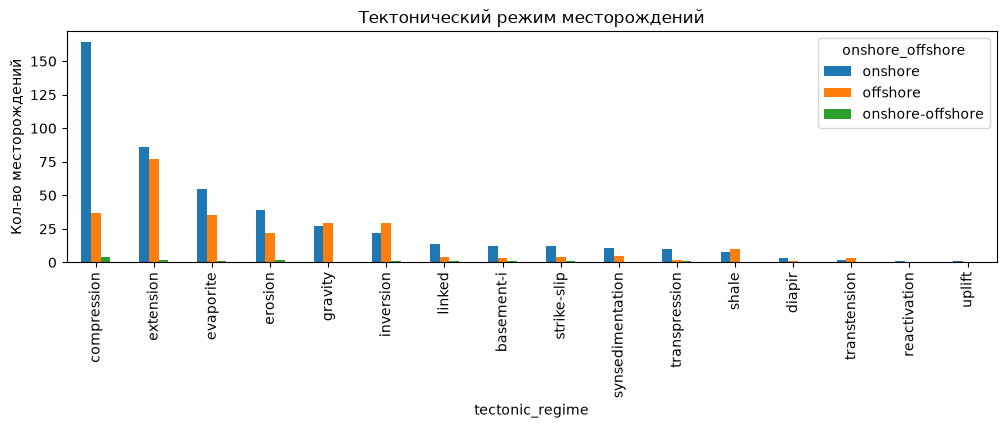

In [80]:
plot_ct(tectonic_regime_df, 'tectonic_regime', 'Тектонический режим месторождений')

Compression, erosion, evaporative, extension более характерны для береговых месторождений. Gravity и inversion - для оффшорных.

#### Структурная обстановка

In [81]:
structural_setting = split_strings(gdf, 'structural_setting')
structural_setting_df = pd.DataFrame(
    {"structural_setting": structural_setting, "onshore_offshore": gdf['onshore_offshore']})
structural_setting_df = structural_setting_df.explode("structural_setting").reset_index(drop=True)

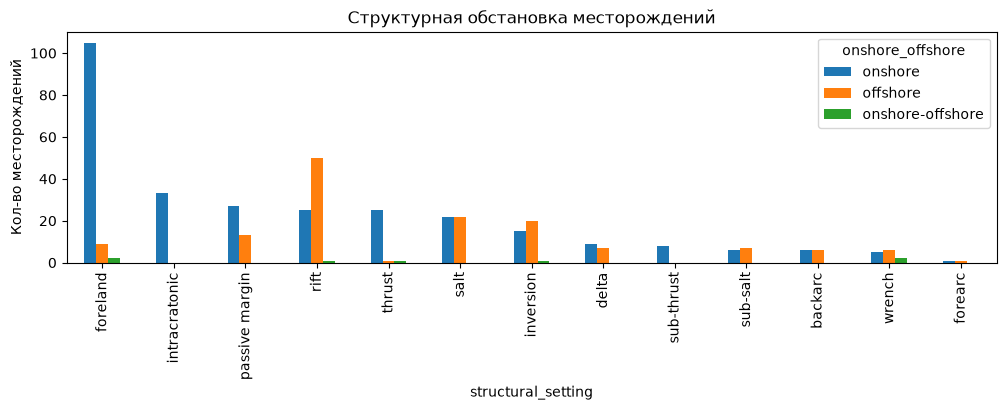

In [82]:
plot_ct(structural_setting_df, 'structural_setting', 'Структурная обстановка месторождений')

Foreland, intracratonic, passive margin, sub-thrust и thrust более характерны для береговых месторождений. А rift и inversion - для оффшорных.

#### Геологический период месторождений

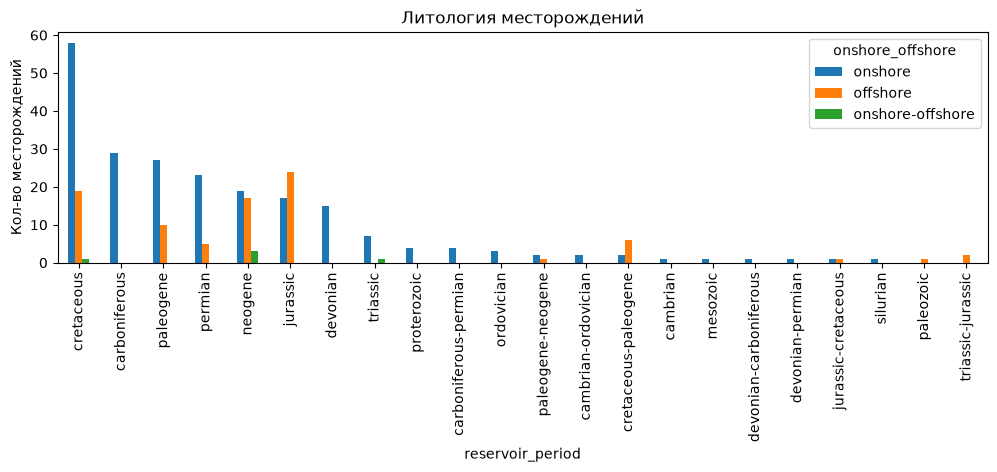

In [83]:
plot_ct(gdf, 'reservoir_period', 'Литология месторождений')

Оффшорные месторождения представлены только меловым, мелово-палеогеновым, юрским, неогеновым, палеогеновым, палеогеново-неогеновым, палеозойским, пермским, триасово-юрским периодами. Среди месторождений юрского периода преобладают оффшорные.   

#### Литология месторождений

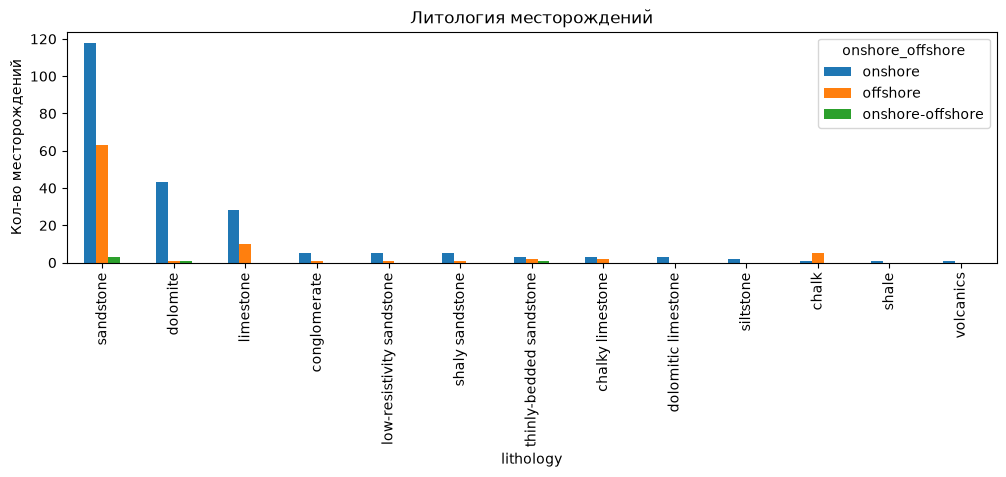

In [84]:
plot_ct(gdf, 'lithology', 'Литология месторождений')

Оффшорные месторождения представлены преимущественно известняками и песчаником.

#### Типы углеводородов

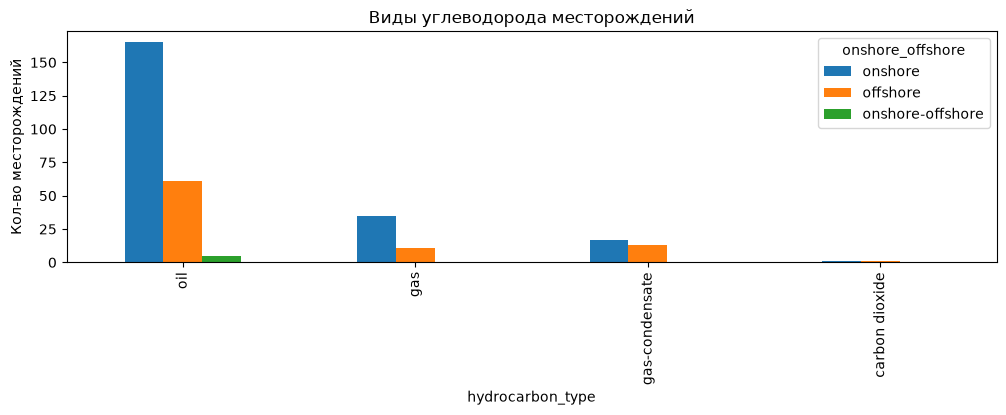

In [85]:
plot_ct(gdf, 'hydrocarbon_type', 'Виды углеводорода месторождений')

Нефтяные месторождения преимущественно располагаются на берегу.

#### Состояние месторождения

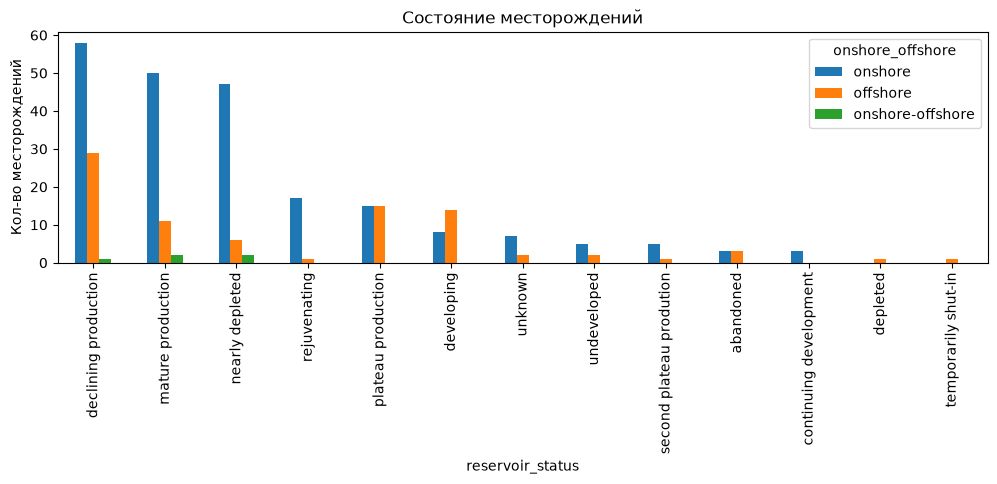

In [86]:
plot_ct(gdf, 'reservoir_status', 'Состояние месторождений')

Статусы "снижение добычи", "поздняя стадия разработки" и "почти исчерпано", "восстановление" преимущественно представлены береговыми месторождениями.

#### Страны

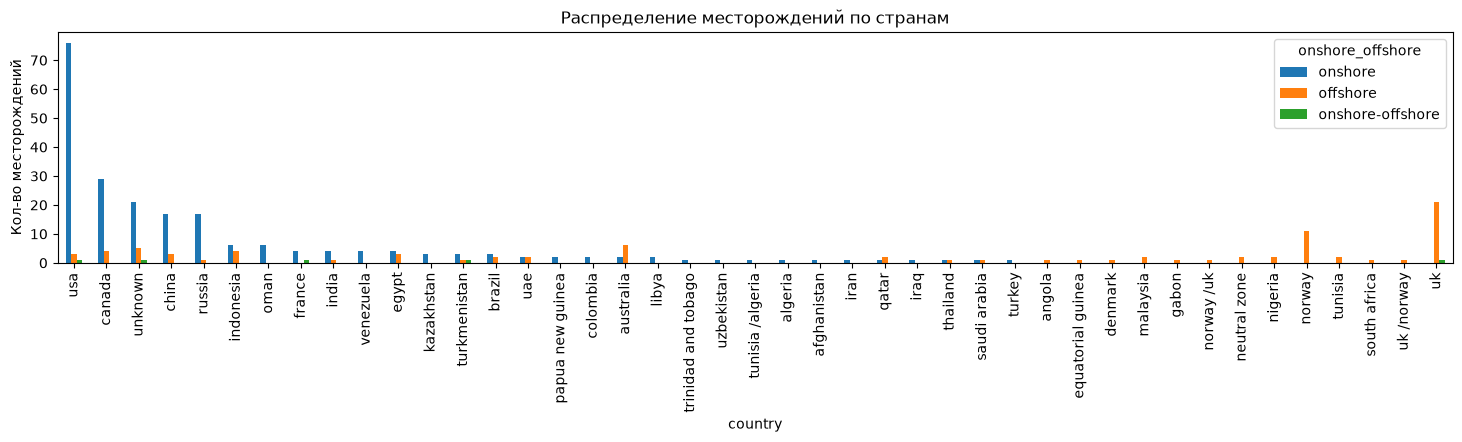

In [87]:
plot_ct(gdf, 'country', 'Распределение месторождений по странам', figsize=(18, 3))

Месторождения достаточно неплохо распределены и по странам.

#### Регионы

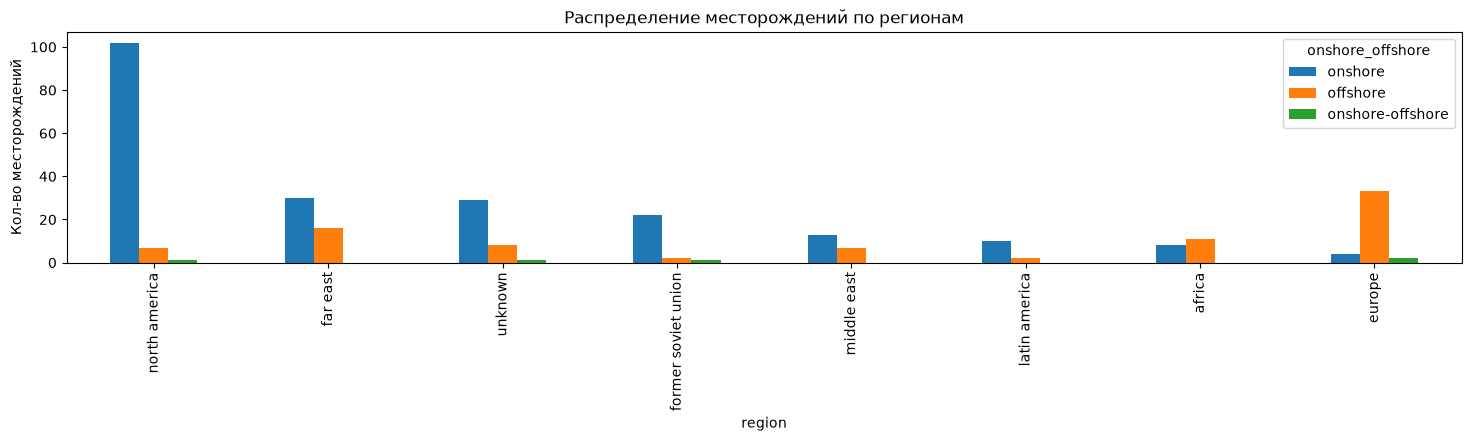

In [88]:
plot_ct(gdf, 'region', 'Распределение месторождений по регионам', figsize=(18, 3))

Можно заметить, что в Северной Америке преобладают береговые месторождения, а в Европе - оффшорные.

#### Численные характеристики месторождений

In [89]:
numeric_cols = ['depth', 'thickness_gross_average_ft', 'thickness_net_pay_average_ft', 'porosity', 'permeability']
gdf_numeric = gdf[numeric_cols + ['onshore_offshore']].copy()
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
gdf_scaled = gdf_numeric.copy()
gdf_scaled[numeric_cols] = scaler.fit_transform(gdf_numeric[numeric_cols])

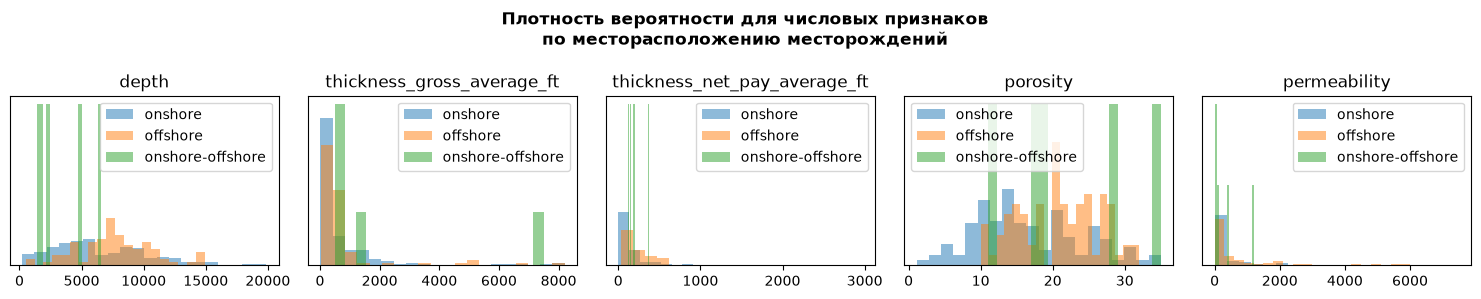

In [90]:
fig, axes = plt.subplots(1, len(numeric_cols), figsize=(3 * len(numeric_cols), 3))
fig.suptitle('Плотность вероятности для числовых признаков\nпо месторасположению месторождений',
             fontsize=12, fontweight='bold', y=0.98)

for i, col in enumerate(numeric_cols):
    for loc in ['onshore', 'offshore', 'onshore-offshore']:
        subset = gdf_numeric[gdf_numeric['onshore_offshore'] == loc][col]
        axes[i].hist(subset, bins=20, alpha=0.5, label=loc, density=True)
    for ax in axes:
        ax.tick_params(left=False, labelleft=False)
    axes[i].set_title(col)
    axes[i].legend()

plt.tight_layout()

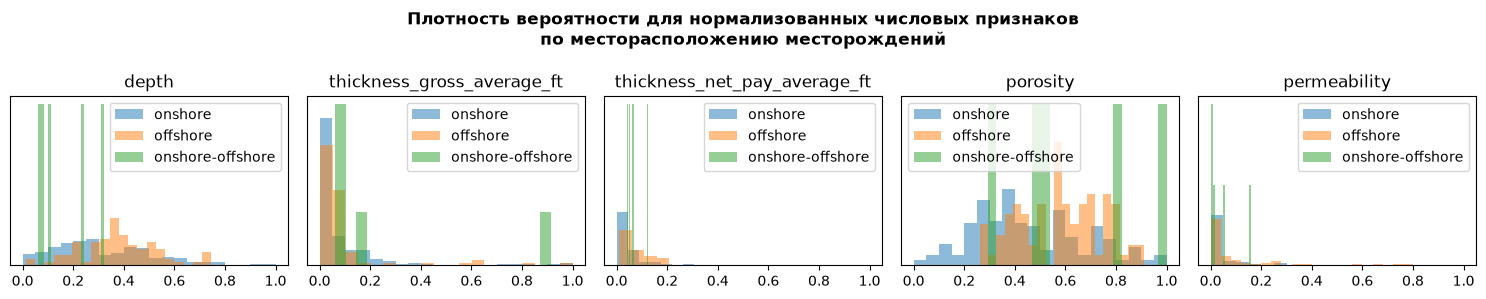

In [91]:
fig, axes = plt.subplots(1, len(numeric_cols), figsize=(3 * len(numeric_cols), 3))
fig.suptitle('Плотность вероятности для нормализованных числовых признаков\nпо месторасположению месторождений',
             fontsize=12, fontweight='bold', y=0.98)

for i, col in enumerate(numeric_cols):
    for loc in ['onshore', 'offshore', 'onshore-offshore']:
        subset = gdf_scaled[gdf_scaled['onshore_offshore'] == loc][col]
        axes[i].hist(subset, bins=20, alpha=0.5, label=loc, density=True)
    for ax in axes:
        ax.tick_params(left=False, labelleft=False)
    axes[i].set_title(col)
    axes[i].legend()

plt.tight_layout()

Смешанные месторождения отличаются по плотности распределения вероятности.

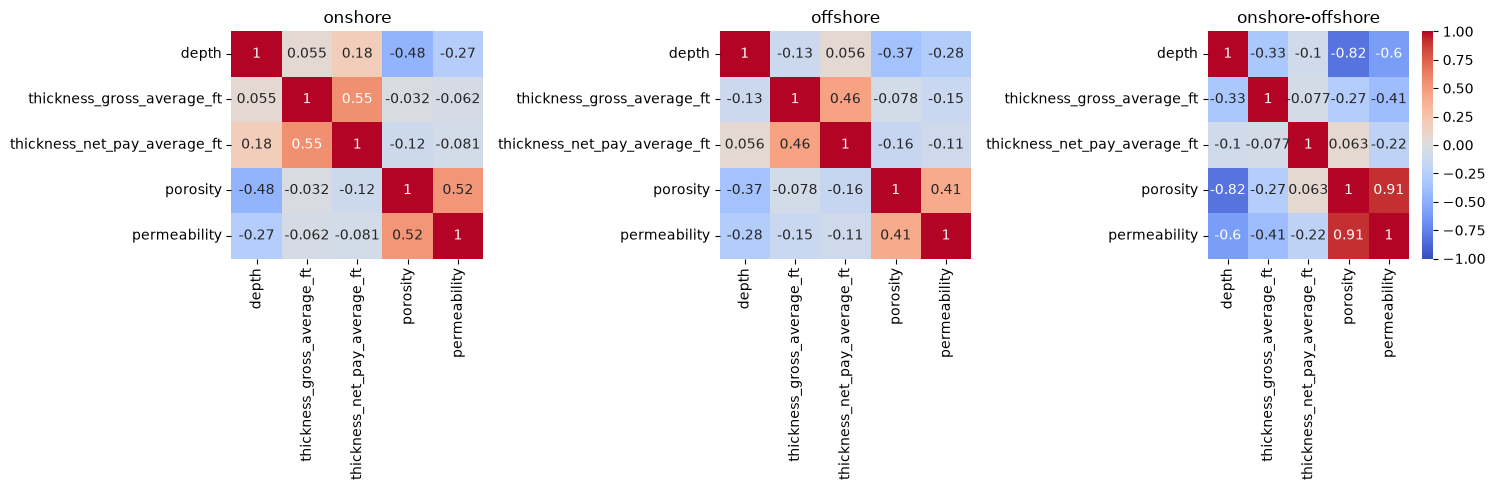

In [92]:
corr_matrix = gdf_numeric.groupby('onshore_offshore')[numeric_cols].corr()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, loc in enumerate(['onshore', 'offshore', 'onshore-offshore']):
    sns.heatmap(corr_matrix.loc[loc], ax=axes[i], annot=True, cmap='coolwarm',
                cbar=(i == 2), vmin=-1, vmax=1)
    axes[i].set_title(loc)
plt.tight_layout()

Более высокие корреляции имеют вариации признака thickness, porosity/permeability и porosity/depth. Важно отметить, что корреляци в группах по разметке разные. Так porosity/depth больше в группе onshore-offshore. Оставим все признаки. Их не так много. Скорректируем, если поймём, что это необходимо на стадии обучения модели.

### Test


#### Ознакомление с датасетом

In [93]:
test_oil_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 133 entries, 0 to 132
Data columns (total 19 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   field_name                    133 non-null    str    
 1   reservoir_unit                133 non-null    str    
 2   country                       120 non-null    str    
 3   region                        117 non-null    str    
 4   basin_name                    125 non-null    str    
 5   tectonic_regime               133 non-null    str    
 6   latitude                      120 non-null    float64
 7   longitude                     117 non-null    float64
 8   operator_company              133 non-null    str    
 9   hydrocarbon_type              133 non-null    str    
 10  reservoir_status              133 non-null    str    
 11  structural_setting            133 non-null    str    
 12  depth                         133 non-null    int64  
 13  reservoir_period

#### Значения категориальных признаков, которые отсутствуют в обучающей выборке 

In [94]:
test_id = test_oil_df['field_name'] + test_oil_df['reservoir_unit']
train_id = train_oil_df['field_name'] + train_oil_df['reservoir_unit']
test_id.name = 'id'
train_id.name = 'id'

print(f"field_name + reservoir_unit: {len(cat_diff(train_id.to_frame(), test_id.to_frame(), 'id'))}")
print(f"field_name: {len(cat_diff(train_oil_df, test_oil_df, 'field_name'))}")
print(f"basin_name: {len(cat_diff(train_oil_df, test_oil_df, 'basin_name'))}")
print(f"reservoir_unit: {len(cat_diff(train_oil_df, test_oil_df, 'reservoir_unit'))}")
print(f"lithology: {len(cat_diff(train_oil_df, test_oil_df, 'lithology'))}")
print(f"tectonic_regime: {len(cat_diff(train_oil_df, test_oil_df, 'tectonic_regime'))}")
print(f"structural_setting: {len(cat_diff(train_oil_df, test_oil_df, 'structural_setting'))}")
print(f"reservoir_status: {len(cat_diff(train_oil_df, test_oil_df, 'reservoir_status'))}")
print(f"region: {len(cat_diff(train_oil_df, test_oil_df, 'region'))}")
print(f"country: {len(cat_diff(train_oil_df, test_oil_df, 'country'))}")
print(f"operator_company: {len(cat_diff(train_oil_df, test_oil_df, 'operator_company'))}")
print(f"hydrocarbon_type: {len(cat_diff(train_oil_df, test_oil_df, 'hydrocarbon_type'))}")

field_name + reservoir_unit: 133
field_name: 103
basin_name: 15
reservoir_unit: 95
lithology: 4
tectonic_regime: 6
structural_setting: 10
reservoir_status: 0
region: 0
country: 6
operator_company: 42
hydrocarbon_type: 2


В тестовой выборке у некоторых признаков есть значения, которые отсутствуют в обучающей выборке. Учтём это при подготовке признаков. 

#### Проверка пустых значений

In [95]:
missing_val_cnts_int_test = test_oil_df.isna().sum()
missing_val_cnts_int_test[missing_val_cnts_int_test > 0]

country       13
region        16
basin_name     8
latitude      13
longitude     16
dtype: int64

Видно, что отсутствуют координаты и бассейн. Будем заполнять эти признаки значениями из справочников.

##### Координаты меторождения Djeitun
На сайте https://sst-ts.com/wellhead-platform-zhdanov-a/ указано, что Джейтун входит в контрактный район Челекен. Возьмём координаты Челекен. Оператор Dragon Oil.

In [96]:
pd.concat([
    test_oil_df[test_oil_df['field_name'] == 'djeitun'][['field_name', 'reservoir_unit', 'latitude', 'longitude', 'operator_company']],
    train_oil_df[train_oil_df['field_name'] == 'cheleken'][['field_name', 'reservoir_unit', 'latitude', 'longitude', 'operator_company']]
])

,field_name,reservoir_unit,latitude,longitude,operator_company
35,djeitun,red series,39.58,NaN,dragon oil
134,cheleken,red series,39.58,53.13,turkmenneft


### Вывод по анализу и ознакомлению с данными 
В процессе ознакомления исследования и анализа датасета мы обнаружили, что:
- сочетание признаков Field Name и Reservoir Unit уникально идентифицируют месторождение;
- часть значений в датасетах отсутствует, стало понятно, как их заполнять;
- отсутствуют координаты и сведения о бассейнах некоторых месторождений, их можно заполнить из справочных материалов;
- отсутствуют значения у некоторых категориальных признаков, их тоже можно заполнить;
- наборы значений категориальных признаков отличаются между обучающей и тестовой выборками, это нужно учитывать при подготовке данных;
- из справочников о метсорождениях и бассейнах можно получить информацию о координатах месторождений и признаке расположения самого бассейна; 
- гео-признаки, основанные на координатах, не всегда работают точно, мы выяснили, что это происходит из-за того, что месторождения находятся действительно в воде, но сичтаются береговыми (в озере Sabine, на острове Bunyu);
- ряд месторождений имеет смешанные локации и связано это с тем, что бассейны могут залегать под сушей и водой, а само месторождение находится на берегу (Huntington Beach);
- признаки тектонического режима и структурной обстановки имеют смешанные категориальные значения для отдельных наблюдений, их нужно разделить и закодировать;
- координаты месторождения Berri Oil Project (Hanifa) указано некорректно, их можно исправить;
- есть неунифицированное сочетание стран в признаке country, его можно скорректировать;
- распределения целевой переменной по разным категориальным признакам помогут нам различать локации месторождений;
- можно заполнить пропущенные координаты месторждения Djeitun в тестовой выборке доступными координатами месторождения Cheleken.

## Подготовка признаков
Подготовим признаки в соответствии с наблюдениями и выводами полученными при ознакомлении и анализе данных:
- заполним пропущенные сведения о координатах месторождений и бассейнов справочными и доступными данными, а остальным пропущенным вменим значение 'Unknown';
- построим ряд признаков, основанных на тексте названий месторождений и их локациях;
- разделим признаки тектонического режима и структурной обстановки;
- уточним координаты месторождения Berri Oil Project (Hanifa);
- унифицируем значение признака страны;
- закодируем категориальные признаки;
- выберем способ масштабирования численных признаков;
- провалидируем корректность построения признаков и отсутствие пропущенных значений;
- сохраним вариации обучающего и тестового датасетов с признаками, подготовленными для разных видов моделей.  

### Импорты

In [1]:
from functools import partial

import geopandas as gpd
import pandas as pd
from shapely import Point
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler

from src.features.geo import extract_polygon
from src.plotting.plots import plot_iqr_boxplot_comparison
from src.preprocessing.preprocessing import construct_basin_location_mapper_with_external, onehot_encode, \
    split_binarize_encode, str_col_vals_to_lower, \
    col_names_to_lower, fill_with_unknown, fill_missing_coords, fill_missing_basins, calc_water_features, \
    calc_ref_features, \
    infer_basin_locations, map_basin_location, onehot_encode_test_data, \
    split_binarize_encode_test_data

### Загрузка данных

#### Обучающий и тестовый датасет

In [2]:
train_oil_df = pd.read_csv("../data/train_oil.csv")
test_oil_df = pd.read_csv("../data/oil_test.csv")

#### Пропущенные координаты, бассейны и мэппинг бассейнов

In [3]:
train_missing_coordinates = pd.read_csv("../data/train_missing_coordinates.csv")
test_missing_coordinates = pd.read_csv("../data/test_missing_coordinates.csv")

In [4]:
missing_basins = pd.read_csv("../data/missing_basins.csv")

In [5]:
basins_mapped = pd.read_csv("../data/basins_mapped.csv")
basins_mapped = basins_mapped.drop(basins_mapped[basins_mapped['basin_name'] == 'unknown'].index).reset_index(
    drop=True).to_dict("records")
external_basin_location_map = {b['basin_name']: b['location'] for b in basins_mapped}

#### Гео-датасеты

In [6]:
land = gpd.read_file("../data/ne_50m_land.zip")['geometry']
land_10m = gpd.read_file("../data/ne_10m_land.zip")['geometry']
ocean_50m = gpd.read_file("../data/ne_50m_ocean.zip")['geometry']
ocean_110m = gpd.read_file("../data/ne_110m_ocean.zip")['geometry']
ne_50m_geography_marine_polys = gpd.read_file("../data/ne_50m_geography_marine_polys.zip")
lakes = gpd.read_file("../data/ne_50m_lakes.zip")['geometry']
geography_regions = gpd.read_file("../data/ne_50m_geography_regions_polys.zip")
rivers_lake_centerlines = gpd.read_file("../data/ne_50m_rivers_lake_centerlines.zip")['geometry']
major_islands = gpd.read_file("../data/ne_50m_coastline.zip")['geometry']
minor_islands = gpd.read_file("../data/ne_10m_minor_islands.zip")['geometry']

### Подготовка данных

In [7]:
train_oil_df = train_oil_df.transform(str_col_vals_to_lower).transform(col_names_to_lower)
test_oil_df = test_oil_df.transform(str_col_vals_to_lower).transform(col_names_to_lower)

In [8]:
train_oil_df = train_oil_df.transform(fill_with_unknown, col='region').transform(fill_with_unknown, col='country')
test_oil_df = test_oil_df.transform(fill_with_unknown, col='region').transform(fill_with_unknown, col='country')

In [9]:
print(f"Пустых значений region в train: {train_oil_df.region.isna().sum()}")
print(f"Пустых значений country в train: {train_oil_df.country.isna().sum()}")
print(f"Пустых значений region в test: {test_oil_df.region.isna().sum()}")
print(f"Пустых значений country в test: {test_oil_df.country.isna().sum()}")

Пустых значений region в train: 0
Пустых значений country в train: 0
Пустых значений region в test: 0
Пустых значений country в test: 0


In [10]:
train_oil_df = train_oil_df.transform(fill_missing_coords, missing_coords_df=train_missing_coordinates)
test_oil_df = test_oil_df.transform(fill_missing_coords, missing_coords_df=test_missing_coordinates)

In [11]:
print(f"Пустых значений latitude в train: {train_oil_df.latitude.isna().sum()}")
print(f"Пустых значений longitude в train: {train_oil_df.longitude.isna().sum()}")
print(f"Пустых значений latitude в test: {test_oil_df.latitude.isna().sum()}")
print(f"Пустых значений longitude в test: {test_oil_df.longitude.isna().sum()}")

Пустых значений latitude в train: 0
Пустых значений longitude в train: 0
Пустых значений latitude в test: 0
Пустых значений longitude в test: 0


In [12]:
train_oil_df = train_oil_df.transform(fill_missing_basins, basin_locations_df=missing_basins)
test_oil_df = test_oil_df.transform(fill_missing_basins, basin_locations_df=missing_basins)

In [13]:
print(f"Пустых значений basin_name в train: {train_oil_df.basin_name.isna().sum()}")
print(f"Пустых значений basin_name в test: {test_oil_df.basin_name.isna().sum()}")

Пустых значений basin_name в train: 0
Пустых значений basin_name в test: 8


In [14]:
test_oil_df = test_oil_df.transform(fill_with_unknown, col='basin_name')
print(f"Пустых значений basin_name в test: {test_oil_df.basin_name.isna().sum()}")

Пустых значений basin_name в test: 0


#### Преобразование в гео датасет

In [15]:
train_gdf = gpd.GeoDataFrame(train_oil_df,
                             geometry=gpd.points_from_xy(train_oil_df.longitude, train_oil_df.latitude),
                             crs="EPSG:4326")
test_gdf = gpd.GeoDataFrame(test_oil_df,
                            geometry=gpd.points_from_xy(test_oil_df.longitude, test_oil_df.latitude),
                            crs="EPSG:4326")

#### Формирование подмножеств геопризнаков

In [16]:
bays = ne_50m_geography_marine_polys[ne_50m_geography_marine_polys.featurecla == 'bay']['geometry']
gulfs = ne_50m_geography_marine_polys[ne_50m_geography_marine_polys.featurecla == 'gulf']['geometry']
straits = ne_50m_geography_marine_polys[ne_50m_geography_marine_polys.featurecla == 'strait']['geometry']
channels = ne_50m_geography_marine_polys[ne_50m_geography_marine_polys.featurecla == 'channel']['geometry']
sounds = ne_50m_geography_marine_polys[ne_50m_geography_marine_polys.featurecla == 'sound']['geometry']
rivers = ne_50m_geography_marine_polys[ne_50m_geography_marine_polys.featurecla == 'river']['geometry']
isthmuses = geography_regions[geography_regions.FEATURECLA == 'Isthmus']['geometry']
deltas = geography_regions[geography_regions.FEATURECLA == 'Delta']['geometry']
coasts = geography_regions[geography_regions.FEATURECLA == 'Coast']['geometry']
lake_regions = geography_regions[geography_regions.FEATURECLA == 'Lake']['geometry']
islands = geography_regions[geography_regions.FEATURECLA.isin(['Island group', 'Island'])]['geometry']

In [17]:
bunyu_coords = Point(117.833, 3.5)
bunyu_island = gpd.GeoSeries(
    [extract_polygon(land_10m[land_10m.geometry.contains(bunyu_coords)].iloc[0], bunyu_coords)],
    crs="EPSG:4326"
)

In [18]:
all_lakes = gpd.GeoDataFrame(
    geometry=pd.concat([lakes, rivers_lake_centerlines, lake_regions], ignore_index=True),
    crs="EPSG:4326").dissolve()

In [19]:
all_islands = gpd.GeoDataFrame(
    geometry=pd.concat([islands, major_islands, minor_islands, bunyu_island], ignore_index=True),
    crs="EPSG:4326").dissolve()

In [20]:
water_feature_datasets = {
    "ocean_50m": ocean_50m,
    "all_islands": all_islands,
    "gulfs": gulfs,
    "straits": straits,
    "deltas": deltas,
    "bays": bays}

### Подготовка признаков

#### Корректировка названия стран

In [21]:
train_gdf.loc[train_gdf['country'] == 'norway /uk', 'country'] = 'uk /norway'
test_gdf.loc[test_gdf['country'] == 'norway /uk', 'country'] = 'uk /norway'

#### Корректировка координат Berri Hanifa

In [22]:
berri_hanifa_coords = (27.11, 49.6389)
berri_hanifa_idx = (train_gdf["field_name"] == "berri") & (train_gdf["reservoir_unit"] == "hanifa")
train_gdf.loc[berri_hanifa_idx, 'latitude'] = berri_hanifa_coords[0]
train_gdf.loc[berri_hanifa_idx, 'longitude'] = berri_hanifa_coords[1]

#### Добавление координат меcторождения Djeitun
На сайте https://sst-ts.com/wellhead-platform-zhdanov-a/ указано, что Джейтун входит в контрактный район Челекен и экплуатируется оператором Dragon Oil, что совпадает со значениями в датасете. Возьмём координаты Челекен.

In [23]:
cheleken_idx = train_gdf['field_name'] == 'cheleken'
djeitun_idx = test_gdf['field_name'] == 'djeitun'
test_gdf.loc[djeitun_idx, 'latitude'] = train_gdf.loc[cheleken_idx, 'latitude']
test_gdf.loc[djeitun_idx, 'longitude'] = train_gdf.loc[cheleken_idx, 'longitude']

#### Расчёт гео-признаков

In [24]:
train_gdf = calc_water_features(train_gdf, water_feature_datasets=water_feature_datasets)
test_gdf = calc_water_features(test_gdf, water_feature_datasets=water_feature_datasets)

In [25]:
water_cols = ['water_pct', 'is_in_water', 'is_on_island', 'is_in_gulf', 'is_in_strait', 'is_in_delta', 'is_in_bay']
print(f"Пустых значений в гео-признаках train:\n{train_gdf[water_cols].isna().sum()}")

Пустых значений в гео-признаках train:
water_pct       0
is_in_water     0
is_on_island    0
is_in_gulf      0
is_in_strait    0
is_in_delta     0
is_in_bay       0
dtype: int64


In [26]:
print(f"Пустых значений в гео-признаках test:\n{test_gdf[water_cols].isna().sum()}")

Пустых значений в гео-признаках test:
water_pct       0
is_in_water     0
is_on_island    0
is_in_gulf      0
is_in_strait    0
is_in_delta     0
is_in_bay       0
dtype: int64


#### Извлечение отметок onshore/offshore, lake из названий месторождения и бассейна

In [27]:
train_gdf = calc_ref_features(train_gdf)
test_gdf = calc_ref_features(test_gdf)

In [28]:
ref_cols = ['ref_onshore', 'ref_offshore', 'ref_lake']
print(f"Пустых значений в ref-признаках train:\n{train_gdf[ref_cols].isna().sum()}")
print(f"Пустых значений в ref-признаках test:\n{test_gdf[ref_cols].isna().sum()}")

Пустых значений в ref-признаках train:
ref_onshore     0
ref_offshore    0
ref_lake        0
dtype: int64
Пустых значений в ref-признаках test:
ref_onshore     0
ref_offshore    0
ref_lake        0
dtype: int64


#### Метки локаций бассейнов (расчётные и внешние)

In [29]:
basin_location, inferred_location_map = infer_basin_locations(train_gdf)
basin_location_map_combined = construct_basin_location_mapper_with_external(basin_location, external_basin_location_map)

train_gdf = map_basin_location(train_gdf,
                               inferred_basin_location_map=inferred_location_map,
                               basin_location_map_combined=basin_location_map_combined)
test_gdf = map_basin_location(test_gdf,
                              inferred_basin_location_map=inferred_location_map,
                              basin_location_map_combined=basin_location_map_combined)

In [30]:
basin_loc_cols = ['basin_location_inferred', 'basin_location_external']
print(f"Пустых значений в признаках расположения бассейнов train:\n{train_gdf[basin_loc_cols].isna().sum()}")
print(f"Пустых значений в признаках расположения бассейнов test:\n{test_gdf[basin_loc_cols].isna().sum()}")

Пустых значений в признаках расположения бассейнов train:
basin_location_inferred    0
basin_location_external    0
dtype: int64
Пустых значений в признаках расположения бассейнов test:
basin_location_inferred    0
basin_location_external    0
dtype: int64


### Разбивка и кодировка композитных признаков 

In [31]:
_onehot_encode = partial(onehot_encode, df=train_gdf)
_onehot_encode_test_data = partial(onehot_encode_test_data, df=test_gdf)

In [32]:
train_country_f, country_t = _onehot_encode(col='country')
train_region_f, region_t = _onehot_encode(col='region')
train_basin_name_f, basin_name_t = _onehot_encode(col='basin_name')
train_operator_company_f, operator_company_t = _onehot_encode(col='operator_company')
train_hydrocarbon_type_f, hydrocarbon_type_t = _onehot_encode(col='hydrocarbon_type')
train_reservoir_period_f, reservoir_period_t = _onehot_encode(col='reservoir_period')
train_lithology_f, lithology_t = _onehot_encode(col='lithology')
train_basin_location_inferred_f, basin_location_inferred_t = _onehot_encode(col='basin_location_inferred')
train_basin_location_external_f, basin_location_external_t = _onehot_encode(col='basin_location_external')

In [33]:
test_country_f = _onehot_encode_test_data(transformer=country_t, col='country')
test_region_f = _onehot_encode_test_data(transformer=region_t, col='region')
test_basin_name_f = _onehot_encode_test_data(transformer=basin_name_t, col='basin_name')
test_operator_company_f = _onehot_encode_test_data(transformer=operator_company_t, col='operator_company')
test_hydrocarbon_type_f = _onehot_encode_test_data(transformer=hydrocarbon_type_t, col='hydrocarbon_type')
test_reservoir_period_f = _onehot_encode_test_data(transformer=reservoir_period_t, col='reservoir_period')
test_lithology_f = _onehot_encode_test_data(transformer=lithology_t, col='lithology')
test_basin_location_inferred_f = _onehot_encode_test_data(transformer=basin_location_inferred_t,
                                                          col='basin_location_inferred')
test_basin_location_external_f = _onehot_encode_test_data(transformer=basin_location_external_t,
                                                          col='basin_location_external')

In [34]:
test_gdf['structural_setting'] = test_gdf['structural_setting'].str.replace("//", "/")

In [35]:
_split_binarize_encode = partial(split_binarize_encode, df=train_gdf)
_split_binarize_encode_test_data = partial(split_binarize_encode_test_data, df=test_gdf)

In [36]:
train_tectonic_regime_f, tectonic_regime_t = _split_binarize_encode(col='tectonic_regime')
train_structural_setting_f, structural_setting_t = _split_binarize_encode(col='structural_setting')

In [37]:
test_tectonic_regime_f = _split_binarize_encode_test_data(transformer=tectonic_regime_t, col='tectonic_regime')
test_structural_setting_f = _split_binarize_encode_test_data(transformer=structural_setting_t, col='structural_setting')

Проверим, есть ли в закодированных признаках колонки для вменённого значения 'unknown' и что группы признаков консистенты между выборками.

In [38]:
train_features = {"country": train_country_f.columns,
                  "region": train_region_f.columns,
                  "basin_name": train_basin_name_f.columns,
                  "operator_company": train_operator_company_f.columns,
                  "hydrocarbon_type": train_hydrocarbon_type_f.columns,
                  "reservoir_period": train_reservoir_period_f.columns,
                  "lithology": train_lithology_f.columns,
                  "basin_location_inferred": train_basin_location_inferred_f.columns,
                  "basin_location_external": train_basin_location_external_f.columns,
                  "tectonic_regime": train_tectonic_regime_f.columns,
                  "structural_setting": train_structural_setting_f.columns}
train_features_check = []
for feature_group, columns in train_features.items():
    result = any('unknown' in c for c in columns)
    train_features_check.append({"dataset": "train" ,"feature_group": feature_group, "contains_unknown": result})

train_features_check_df = pd.DataFrame(train_features_check)

In [39]:
test_features = {"country": test_country_f.columns,
                 "region": test_region_f.columns,
                 "basin_name": test_basin_name_f.columns,
                 "operator_company": test_operator_company_f.columns,
                 "hydrocarbon_type": test_hydrocarbon_type_f.columns,
                 "reservoir_period": test_reservoir_period_f.columns,
                 "lithology": test_lithology_f.columns,
                 "basin_location_inferred": test_basin_location_inferred_f.columns,
                 "basin_location_external": test_basin_location_external_f.columns,
                 "tectonic_regime": test_tectonic_regime_f.columns,
                 "structural_setting": test_structural_setting_f.columns}
test_features_check = []
for feature_group, columns in test_features.items():
    result = any('unknown' in c for c in columns)
    test_features_check.append({"dataset": "test" ,"feature_group": feature_group, "contains_unknown": result})
test_features_check_df = pd.DataFrame(test_features_check)

In [40]:
pd.concat([train_features_check_df, test_features_check_df]).pivot(index='feature_group', 
                                                                   columns='dataset',values='contains_unknown').reset_index()

dataset,feature_group,test,train
0,basin_location_external,False,False
1,basin_location_inferred,False,False
2,basin_name,False,False
3,country,True,True
4,hydrocarbon_type,False,False
5,lithology,False,False
6,operator_company,False,False
7,region,True,True
8,reservoir_period,False,False
9,structural_setting,False,False


### Масштабирование числовых признаков
Попробуем подобрать алгоритм масштабирования численных признаков. `water_pct` не смотрим, т.к. признак вариьруется [0, 1].  

In [41]:
numeric_cols = ['depth', 'thickness_gross_average_ft', 'thickness_net_pay_average_ft', 'porosity', 'permeability']
standard_scaler = StandardScaler()
minmax_scaler = MinMaxScaler()
robust_scaler = RobustScaler()

train_numeric = train_gdf[numeric_cols].copy()
test_numeric = test_gdf[numeric_cols].copy()

standard_scaler.fit(train_numeric)
minmax_scaler.fit(train_numeric)
robust_scaler.fit(train_numeric)

train_std_scaled = pd.DataFrame(standard_scaler.transform(train_numeric), columns=numeric_cols)
test_std_scaled = pd.DataFrame(standard_scaler.transform(test_numeric), columns=numeric_cols)

train_mm_scaled = pd.DataFrame(minmax_scaler.transform(train_numeric), columns=numeric_cols)
test_mm_scaled = pd.DataFrame(minmax_scaler.transform(test_numeric), columns=numeric_cols)

train_robust_scaled = pd.DataFrame(robust_scaler.transform(train_numeric), columns=numeric_cols)
test_robust_scaled = pd.DataFrame(robust_scaler.transform(test_numeric), columns=numeric_cols)

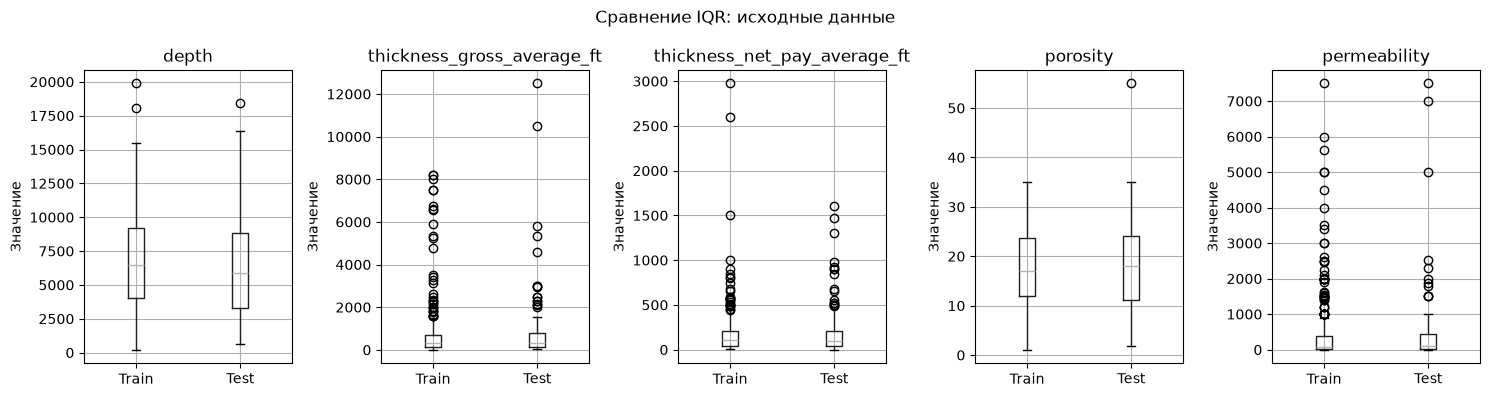

In [42]:
plot_iqr_boxplot_comparison(train_df=train_numeric, test_df=test_numeric, title="исходные данные")

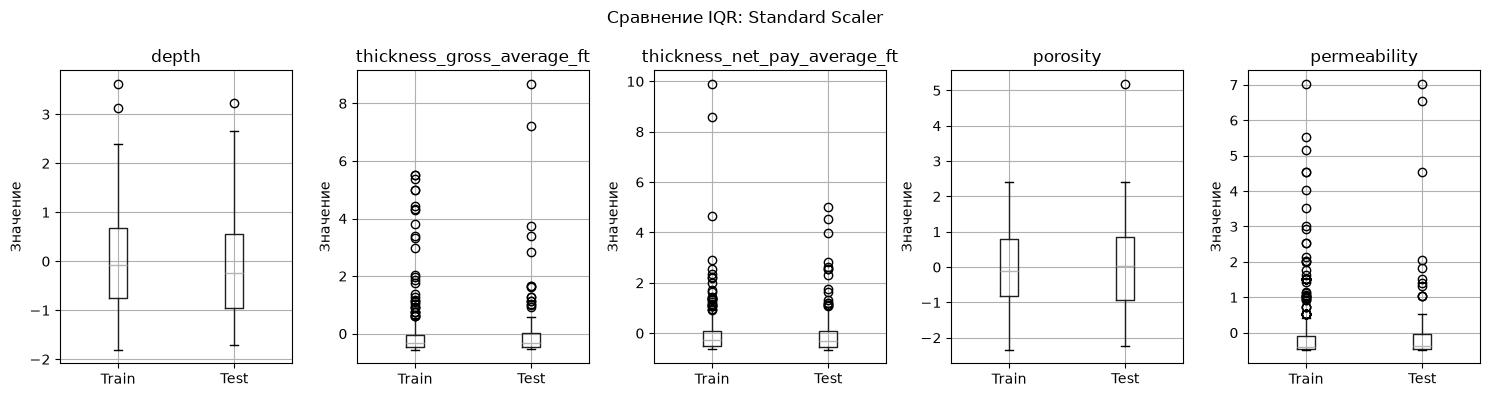

In [43]:
plot_iqr_boxplot_comparison(train_df=train_std_scaled, test_df=test_std_scaled, title="Standard Scaler")

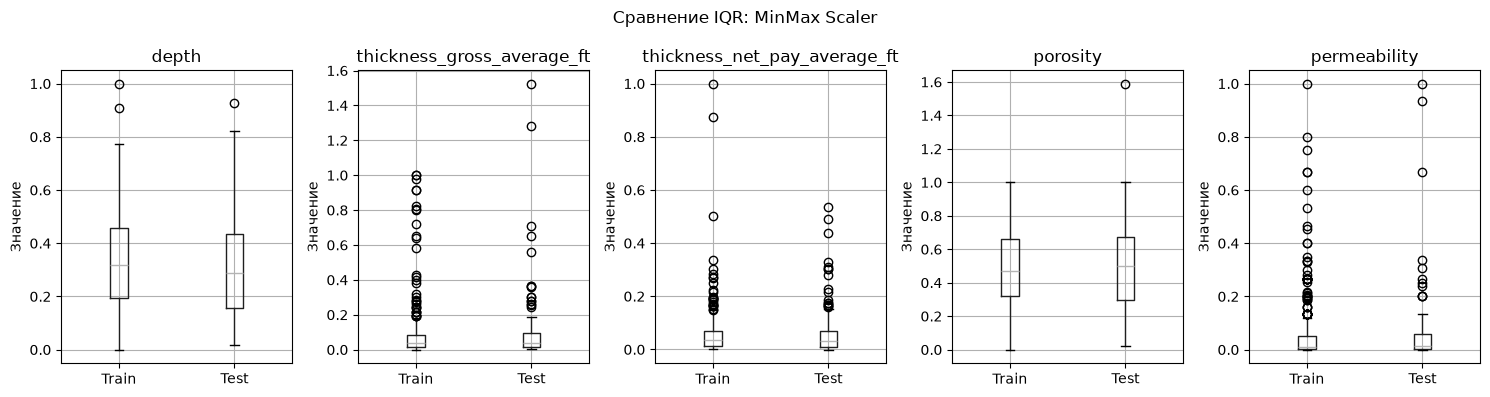

In [44]:
plot_iqr_boxplot_comparison(train_df=train_mm_scaled, test_df=test_mm_scaled, title="MinMax Scaler")

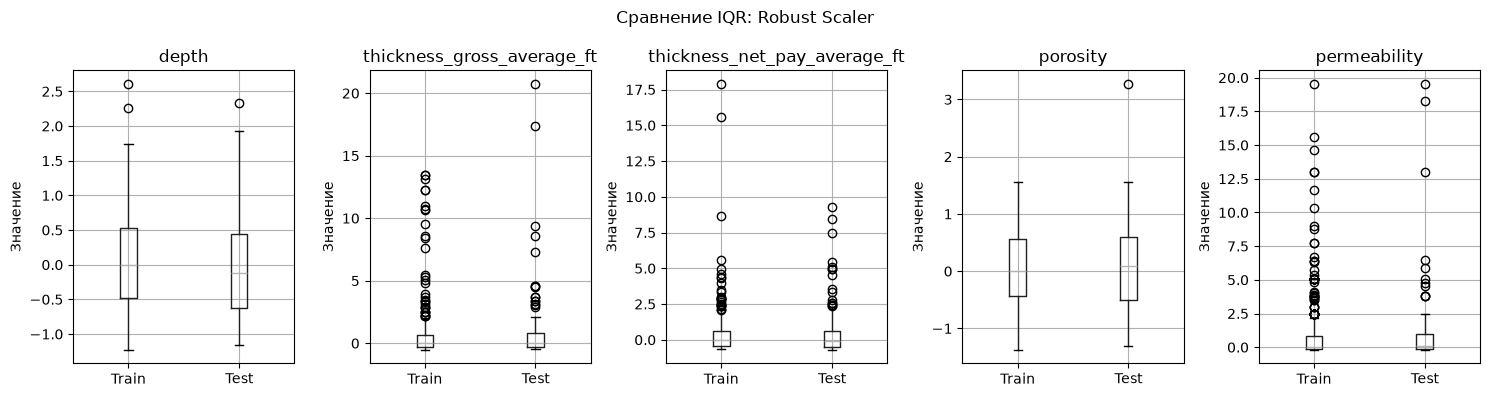

In [45]:
plot_iqr_boxplot_comparison(train_df=train_robust_scaled, test_df=test_robust_scaled, title="Robust Scaler")

В целом, выглядит, что больше всего подойдёт только масштабированные признаки по Min-Max. Все остальные имеют большой межквартильный разброс и могут снизить качество модели. 

### Конверсия бинарных признаков в целочисленные 

In [46]:
binary_cols = ['is_in_water', 'is_on_island', 'is_in_gulf', 'is_in_strait', 'is_in_delta', 'is_in_bay', 'ref_onshore',
               'ref_offshore', 'ref_lake']
train_binary_features = train_gdf[binary_cols].astype(float).copy()
test_binary_features = test_gdf[binary_cols].astype(float).copy()

### Сбор признаков

#### Catboost
Соберём признаки для Catboost. Catboost не требует OneHot-кодирования категориальных признаков и достаточно хорошо работает с немасштабированными признаками. 
Можно добавить категориальные признаки, как есть, за исключением признаков тектонического режима и структурной обстановки. Эти содержали несколько значений на одно наблюдение, следовательно, их пришлось разделить и закодировать.

In [47]:
id_cols = ['field_name', 'reservoir_unit']
catboost_feature_columns = ['country',
                            'region',
                            'basin_name',
                            'operator_company',
                            'hydrocarbon_type',
                            'reservoir_status',
                            'reservoir_period',
                            'lithology',
                            'basin_location_inferred',
                            'basin_location_external']

In [48]:
pd.concat([
    train_gdf[id_cols],
    train_gdf[catboost_feature_columns],
    train_tectonic_regime_f,
    train_structural_setting_f,
    train_numeric,
    train_gdf[['water_pct']],
    train_binary_features,
    train_gdf[['onshore_offshore']]
], axis=1).to_csv("../data/catboost_train_20260725.csv", index=False)


In [49]:
pd.concat([
    test_gdf[id_cols],
    test_gdf[catboost_feature_columns],
    test_tectonic_regime_f,
    test_structural_setting_f,
    test_numeric,
    test_gdf[['water_pct']],
    test_binary_features
], axis=1).to_csv("../data/catboost_test_20260725.csv", index=False)

#### Encoded
Сохраним закодированные признаки для других моделей.

In [50]:
encoded_train_dataset = pd.concat([
    train_gdf[id_cols],
    train_country_f,
    train_region_f,
    train_basin_name_f,
    train_operator_company_f,
    train_hydrocarbon_type_f,
    train_reservoir_period_f,
    train_lithology_f,
    train_basin_location_inferred_f,
    train_basin_location_external_f,
    train_tectonic_regime_f,
    train_structural_setting_f,
    train_mm_scaled,
    train_gdf[['water_pct']],
    train_binary_features,
    train_gdf[['onshore_offshore']]], axis=1)

In [51]:
encoded_train_dataset_na = encoded_train_dataset.isna().sum()
encoded_train_dataset_na_zero = (encoded_train_dataset_na > 0)
encoded_train_dataset_na[encoded_train_dataset_na_zero]

Series([], dtype: int64)

In [52]:
encoded_train_dataset.to_csv("../data/encoded_train_20260725.csv", index=False)

In [53]:
encoded_test_dataset = pd.concat([
    test_gdf[id_cols],
    test_country_f,
    test_region_f,
    test_basin_name_f,
    test_operator_company_f,
    test_hydrocarbon_type_f,
    test_reservoir_period_f,
    test_lithology_f,
    test_basin_location_inferred_f,
    test_basin_location_external_f,
    test_tectonic_regime_f,
    test_structural_setting_f,
    test_mm_scaled,
    test_gdf[['water_pct']],
    test_binary_features], axis=1)

In [54]:
encoded_test_dataset_na = encoded_test_dataset.isna().sum()
encoded_test_dataset_na_zero = (encoded_test_dataset_na > 0)
encoded_test_dataset_na[encoded_test_dataset_na_zero]

Series([], dtype: int64)

In [55]:
encoded_test_dataset.to_csv("../data/encoded_test_20260725.csv", index=False)

### Выводы к предподготовке данных 
Мы подготовили признаки в соответствии с наблюдениями и выводами полученными при ознакомлении и анализе данных:
- заполнили пропущенные сведения о координатах месторождений и бассейнов справочными и доступными данными, а остальным пропущенным вменим значение 'Unknown';
- построили ряд признаков, основанных на тексте названий месторождений и их локациях;
- разделили признаки тектонического режима и структурной обстановки;
- уточнили координаты месторождения Berri Oil Project (Hanifa);
- унифицировали значение признака страны;
- закодировали категориальные признаки;
- выбрали способ масштабирования численных признаков;
- провалидировали корректность построения признаков и отсутствие пропущенных значений;
- сохранили вариации обучающего и тестового датасетов с признаками, подготовленными для разных видов моделей.  

## Обучение моделей и отправка результата
Подготовим данные к обучению, обучим несколько моделей, выберем лучшую, проведём оптимизацию гиперпараметров. Постараемся понять, как ошибаются модели. 

Отправим результат предсказания на проверочном датасете на Kaggle.

### Импорты

In [1]:
import numpy as np
import pandas as pd
from catboost import Pool, cv, CatBoostClassifier
from matplotlib import pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, make_scorer
from sklearn.model_selection import cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from IPython.display import display, Image
from src.submission.kaggle_integration import KaggleSubmitter

### Загрузка данных

In [2]:
catboost_train_20260724 = pd.read_csv('../data/catboost_train_20260724.csv')

catboost_train_df = pd.read_csv("../data/catboost_train_20260725.csv")
catboost_test_df = pd.read_csv("../data/catboost_test_20260725.csv")

encoded_train_df = pd.read_csv("../data/encoded_train_20260725.csv")
encoded_test_df = pd.read_csv("../data/encoded_test_20260725.csv")

target_col = "onshore_offshore"
id_cols = ['field_name', 'reservoir_unit']

### Подготовка обучающих множеств

In [3]:
berri_hanifa_idx = (catboost_train_df["field_name"] == "berri") & (catboost_train_df["reservoir_unit"] == "hanifa")
sabine_lake_idx = (catboost_train_df["field_name"].str.contains("sabine"))
bunyu_island_idx = (catboost_train_df["field_name"].str.contains("bunyu"))
wytch_farm_idx = (catboost_train_df["field_name"].str.contains("wytch"))
tia_juana_idx = (catboost_train_df["field_name"].str.contains("tia juana"))
cheleken_idx = (catboost_train_df["field_name"].str.contains("cheleken"))
parentis_idx = (catboost_train_df["field_name"].str.contains("parentis"))
huntington_idx = (catboost_train_df["field_name"].str.contains("huntington"))

mixed_class_fields = (wytch_farm_idx | tia_juana_idx | cheleken_idx | parentis_idx | huntington_idx)
interesting_fields = (berri_hanifa_idx | sabine_lake_idx | bunyu_island_idx)
combined_fields = (berri_hanifa_idx | sabine_lake_idx | bunyu_island_idx |
                   wytch_farm_idx | tia_juana_idx | cheleken_idx |
                   parentis_idx | huntington_idx)

mixed_class_indices = mixed_class_fields[mixed_class_fields].index.tolist()
interesting_indices = interesting_fields[interesting_fields].index.tolist()
combined_indices = combined_fields[combined_fields].index.tolist()

In [4]:
catboost_train_df[combined_fields][[*id_cols, target_col]]

,field_name,reservoir_unit,onshore_offshore
64,wytch farm,sherwood,onshore-offshore
92,tia juana,la rosa-lagunillas (tia juana onshore area),onshore-offshore
109,north sabine lake,lower hackberry (frio),onshore
134,cheleken,red series,onshore-offshore
185,parentis,unnamed,onshore-offshore
220,huntington beach,jones zone,onshore-offshore
292,berri,hanifa,offshore
298,bunyu,tarakan-santul-tabul-bunyu,onshore


In [5]:
catboost_train_df[combined_fields][[*id_cols, target_col]].equals(
    encoded_train_df[combined_fields][[*id_cols, target_col]])

True

In [6]:
cb_feature_cols = [c for c in catboost_train_df.columns if c not in [target_col, *id_cols]]
cb_X, cb_y = catboost_train_df[cb_feature_cols], catboost_train_df[target_col]
cb_le = LabelEncoder()
cb_y_encoded = cb_le.fit_transform(cb_y)
pd.concat([cb_y, pd.Series(cb_y_encoded)], axis=1).value_counts()

onshore_offshore  0
onshore           1    218
offshore          0     86
onshore-offshore  2      5
Name: count, dtype: int64

In [7]:
enc_feature_cols = [c for c in encoded_train_df.columns if c not in [target_col, *id_cols]]
enc_X, enc_y = encoded_train_df[enc_feature_cols], encoded_train_df[target_col]
enc_le = LabelEncoder()
enc_y_encoded = enc_le.fit_transform(enc_y)
pd.concat([enc_y, pd.Series(enc_y_encoded)], axis=1).value_counts()

onshore_offshore  0
onshore           1    218
offshore          0     86
onshore-offshore  2      5
Name: count, dtype: int64

In [8]:
(enc_y_encoded == cb_y_encoded).all()

np.True_

In [9]:
y_encoded = cb_y_encoded

In [10]:
split_params = dict(test_size=0.2, random_state=42, stratify=y_encoded)

In [11]:
enc_X_train, enc_X_test, enc_y_train, enc_y_test = train_test_split(enc_X, y_encoded, **split_params)
cb_X_train, cb_X_test, cb_y_train, cb_y_test = train_test_split(cb_X, y_encoded, **split_params)

In [12]:
enc_X_train.index.equals(cb_X_train.index)

True

In [13]:
catboost_train_df.loc[cb_X_train[mixed_class_fields].index, [*id_cols, target_col]]

/tmp/ipykernel_1858379/3979259546.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  catboost_train_df.loc[cb_X_train[mixed_class_fields].index, [*id_cols, target_col]]


,field_name,reservoir_unit,onshore_offshore
64,wytch farm,sherwood,onshore-offshore
92,tia juana,la rosa-lagunillas (tia juana onshore area),onshore-offshore
185,parentis,unnamed,onshore-offshore
134,cheleken,red series,onshore-offshore


In [14]:
catboost_train_df.loc[cb_X_test[mixed_class_fields].index, [*id_cols, target_col]]

/tmp/ipykernel_1858379/2827046411.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  catboost_train_df.loc[cb_X_test[mixed_class_fields].index, [*id_cols, target_col]]


,field_name,reservoir_unit,onshore_offshore
220,huntington beach,jones zone,onshore-offshore


Только Huntington Beach отнесён к тестовой выборке, а все остальные - к обучающей.

### Decision Tree + Random Forest

In [15]:
dt_params = dict(max_depth=3, min_samples_split=5, min_samples_leaf=3, random_state=42)
rf_params = dict(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
dt = DecisionTreeClassifier(**dt_params)
rf = RandomForestClassifier(**rf_params)
cv_dt_rf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_scores = cross_val_score(rf, enc_X, enc_y_encoded, cv=cv_dt_rf, scoring="neg_log_loss")
dt_scores = cross_val_score(dt, enc_X, enc_y_encoded, cv=cv_dt_rf, scoring="neg_log_loss")
print(f"Random Forest: средняя LogLoss-мера на кросс-валидации: {-rf_scores.mean():.4f} (+/- {rf_scores.std():.4f})")
print(f"Decision Tree: средняя LogLoss-мера на кросс-валидации: {-dt_scores.mean():.4f} (+/- {dt_scores.std():.4f})")

Random Forest: средняя LogLoss-мера на кросс-валидации: 0.1160 (+/- 0.0072)
Decision Tree: средняя LogLoss-мера на кросс-валидации: 0.6196 (+/- 0.5049)


In [16]:
random_forest = RandomForestClassifier(**rf_params)
random_forest.fit(enc_X_train, enc_y_train)
random_forest_enc_y_pred = random_forest.predict(enc_X_test)
random_forest_micro = f1_score(enc_y_test, random_forest_enc_y_pred, average='micro')
random_forest_macro = f1_score(enc_y_test, random_forest_enc_y_pred, average='macro')
print(f"Random Forest: F1-мера (micro) на разделении train/test: {random_forest_micro:.15f}")
print(f"Random Forest: F1-мера (macro) на разделении train/test: {random_forest_macro:.15f}")

Random Forest: F1-мера (micro) на разделении train/test: 0.983870967741935
Random Forest: F1-мера (macro) на разделении train/test: 0.662921348314607


In [17]:
decision_tree = DecisionTreeClassifier(**dt_params)
decision_tree.fit(enc_X_train, enc_y_train)
decision_tree_y_pred = decision_tree.predict(enc_X_test)
decision_tree_micro = f1_score(enc_y_test, decision_tree_y_pred, average='micro')
decision_tree_macro = f1_score(enc_y_test, decision_tree_y_pred, average='macro')
print(f"Decision Tree: F1-мера (micro) на разделении train/test: {decision_tree_micro:.15f}")
print(f"Decision Tree: F1-мера (macro) на разделении train/test: {decision_tree_macro:.15f}")

Decision Tree: F1-мера (micro) на разделении train/test: 0.983870967741935
Decision Tree: F1-мера (macro) на разделении train/test: 0.662921348314607


### Catboost

In [18]:
cat_cols = cb_X.select_dtypes(include=['object', 'category', 'str']).columns.tolist()
cb_X[cat_cols] = cb_X[cat_cols].astype('category')

In [19]:
pool = Pool(cb_X, cb_y_encoded, cat_features=cat_cols)

In [20]:
cb_params = {'loss_function': 'MultiClass', 'iterations': 150, 'verbose': False}
cb_params_micro = {**cb_params, 'eval_metric': 'TotalF1:average=Micro'}
cb_params_macro = {**cb_params, 'eval_metric': 'TotalF1:average=Macro'}
cv_settings = {'pool': pool, 'fold_count': 5, 'stratified': True, 'partition_random_seed': 42, "as_pandas": True}

cv_micro_results = cv(**cv_settings, params=cb_params_micro)
cv_macro_results = cv(**cv_settings, params=cb_params_macro)

Training on fold [0/5]

bestTest = 0.9841269841
bestIteration = 0

Training on fold [1/5]

bestTest = 0.9838709677
bestIteration = 0

Training on fold [2/5]

bestTest = 0.9838709677
bestIteration = 0

Training on fold [3/5]

bestTest = 0.9672131148
bestIteration = 2

Training on fold [4/5]

bestTest = 0.9836065574
bestIteration = 1

Training on fold [0/5]

bestTest = 0.6629213483
bestIteration = 0

Training on fold [1/5]

bestTest = 0.6629213483
bestIteration = 0

Training on fold [2/5]

bestTest = 0.6629213483
bestIteration = 0

Training on fold [3/5]

bestTest = 0.6493909192
bestIteration = 5

Training on fold [4/5]

bestTest = 0.662835249
bestIteration = 1


In [21]:
best_catboost_micro = cv_micro_results['test-TotalF1:average=Micro-mean'].max()
best_catboost_macro = cv_macro_results['test-TotalF1:average=Macro-mean'].max()
print(f"Catboost: лучшее значение F1-меры (micro): {best_catboost_micro:.15f}")
print(f"Catboost: лучшее значение F1-меры (macro): {best_catboost_macro:.15f}")

Catboost: лучшее значение F1-меры (micro): 0.980537718348401
Catboost: лучшее значение F1-меры (macro): 0.660198042628865


In [22]:
train_pool = Pool(cb_X_train, cb_y_train, cat_features=cat_cols)
eval_pool = Pool(cb_X_test, cb_y_test, cat_features=cat_cols)

In [23]:
cb_model_micro = CatBoostClassifier(**cb_params_micro)
cb_model_macro = CatBoostClassifier(**cb_params_macro)

cb_model_micro.fit(train_pool, eval_set=eval_pool, early_stopping_rounds=50)
cb_model_macro.fit(train_pool, eval_set=eval_pool, early_stopping_rounds=50)

CatBoostClassifier(eval_metric='TotalF1:average=Macro', iterations=150, loss_function='MultiClass', verbose=False)

In [24]:
cb_eval_micro = max(cb_model_micro.get_evals_result()['validation']['TotalF1:average=Micro'])
cb_eval_macro = max(cb_model_macro.get_evals_result()['validation']['TotalF1:average=Macro'])
print(f"Catboost: лучшее значение F1-меры (micro): {cb_eval_micro:.15f}")
print(f"Catboost: лучшее значение F1-меры (macro): {cb_eval_macro:.15f}")

Catboost: лучшее значение F1-меры (micro): 0.983870967741935
Catboost: лучшее значение F1-меры (macro): 0.662921348314607


### Сравнение и выбор моделей

In [25]:
pd.DataFrame([
    {"model": "Random Forest", "F1 Micro": random_forest_micro, "F1 Macro": random_forest_macro},
    {"model": "Decision Tree", "F1 Micro": decision_tree_micro, "F1 Macro": decision_tree_macro},
    {"model": "Catboost", "F1 Micro": cb_eval_micro, "F1 Macro": cb_eval_macro},
]).sort_values(["F1 Micro", "F1 Macro"], ascending=[False, False])

,model,F1 Micro,F1 Macro
0,Random Forest,0.983871,0.662921
1,Decision Tree,0.983871,0.662921
2,Catboost,0.983871,0.662921


Все модели показывают идентичные скоры. 

#### Как модели ошибаются?
Посмотрим, как модели ошибаются.

In [26]:
cb_micro_preds = cb_model_micro.predict(cb_X)
cb_macro_preds = cb_model_macro.predict(cb_X)
rf_preds = random_forest.predict(enc_X)
dt_preds = decision_tree.predict(enc_X)

cb_micro_errors = np.where(cb_micro_preds.flatten() != cb_y_encoded)[0]
cb_macro_errors = np.where(cb_macro_preds.flatten() != cb_y_encoded)[0]
rf_errors = np.where(rf_preds.flatten() != enc_y_encoded)[0]
dt_errors = np.where(dt_preds.flatten() != enc_y_encoded)[0]

In [27]:
def check_mispredictions(error_idx, preds):
    eval_df = catboost_train_df.loc[error_idx, [*id_cols, target_col]]
    eval_df['predicted'] = cb_le.inverse_transform(preds[error_idx].flatten())
    return eval_df

In [28]:
micro_mispredictions = check_mispredictions(cb_micro_errors, cb_micro_preds)
macro_mispredictions = check_mispredictions(cb_macro_errors, cb_macro_preds)
assert micro_mispredictions.equals(macro_mispredictions)
micro_mispredictions

,field_name,reservoir_unit,onshore_offshore,predicted
64,wytch farm,sherwood,onshore-offshore,onshore
92,tia juana,la rosa-lagunillas (tia juana onshore area),onshore-offshore,onshore
109,north sabine lake,lower hackberry (frio),onshore,offshore
134,cheleken,red series,onshore-offshore,offshore
185,parentis,unnamed,onshore-offshore,onshore
220,huntington beach,jones zone,onshore-offshore,onshore
298,bunyu,tarakan-santul-tabul-bunyu,onshore,offshore


Большинство ошибок Catboost в смешанных классах.

In [29]:
check_mispredictions(dt_errors, dt_preds)

,field_name,reservoir_unit,onshore_offshore,predicted
34,villeperdue,dalle nacree,onshore,onshore-offshore
92,tia juana,la rosa-lagunillas (tia juana onshore area),onshore-offshore,onshore
134,cheleken,red series,onshore-offshore,offshore
220,huntington beach,jones zone,onshore-offshore,onshore
298,bunyu,tarakan-santul-tabul-bunyu,onshore,offshore


Decision Tree не справляется со смешанными классами. DT не распознало месторождение не берегу Маракайбо, хотя оно было в обучающей выборке. Сложными оказались остров Bunyu, Huntington Beach и Cheleken.

По-видимому, не хватает признаков и наблюдений.

In [30]:
check_mispredictions(rf_errors, rf_preds)

,field_name,reservoir_unit,onshore_offshore,predicted
220,huntington beach,jones zone,onshore-offshore,onshore


Random Forest не справился только с Huntington Beach. Продолжим с Random Forest.

### Оптимизация гиперпараметров
Сфокусируемся на оптимизации гиперпараметров модели на основе Random Forest с упором на F1 Macro, чтобы попытаться улучшить качество в части классов, для которых мало наблюдений.

In [31]:
param_grid = {
    'n_estimators': [50, 150, 200],
    'max_depth': [2, 3, 4, 5, 7, 10, None],
    'min_samples_split': [2, 3, 5],
    'criterion': ['entropy', 'gini'],
    'random_state': [42]
}

rf = RandomForestClassifier()
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scorer = make_scorer(f1_score, average='macro')

grid = GridSearchCV(rf, param_grid, cv=cv, scoring=scorer, n_jobs=-1)
grid.fit(enc_X, enc_y_encoded)

print(f"F1-мера (macro) для лучшего набора параметров: {grid.best_score_:.4f}")
print(f"Лучший набор параметров: {grid.best_params_}")

F1-мера (macro) для лучшего набора параметров: 0.6617
Лучший набор параметров: {'criterion': 'entropy', 'max_depth': 3, 'min_samples_split': 2, 'n_estimators': 150, 'random_state': 42}


In [32]:
best_random_forest = RandomForestClassifier(**grid.best_params_)
best_random_forest.fit(enc_X_train, enc_y_train)
best_random_forest_enc_y_pred = best_random_forest.predict(enc_X_test)
best_random_forest_macro = f1_score(enc_y_test, best_random_forest_enc_y_pred, average='macro')
print(
    f"Random Forest с лучшим набором параметров: F1-мера (macro) на разделении train/test: {best_random_forest_macro:.15f}")

Random Forest с лучшим набором параметров: F1-мера (macro) на разделении train/test: 0.662921348314607


In [33]:
best_rf_preds = best_random_forest.predict(enc_X)
best_rf_errors = np.where(best_rf_preds.flatten() != enc_y_encoded)[0]
check_mispredictions(best_rf_errors, best_rf_preds)

,field_name,reservoir_unit,onshore_offshore,predicted
64,wytch farm,sherwood,onshore-offshore,onshore
92,tia juana,la rosa-lagunillas (tia juana onshore area),onshore-offshore,onshore
97,dzhigalybeg,red series,offshore,onshore
134,cheleken,red series,onshore-offshore,onshore
185,parentis,unnamed,onshore-offshore,onshore
220,huntington beach,jones zone,onshore-offshore,onshore


Как видно, перебор гиперпараметров не помог улучшить ситуацию.

### Значимость признаков

In [34]:
imp_df = pd.DataFrame({'feature': enc_X.columns.tolist(), 'importance': random_forest.feature_importances_})

In [35]:
for feature in cb_feature_cols:
    feature_indices = imp_df['feature'].str.startswith(feature) 
    imp_df.loc[feature_indices, 'feature'] = feature

for feature in ['structural_setting', 'tectonic_regime']:
    feature_indices = imp_df['feature'].str.startswith(feature) 
    imp_df.loc[feature_indices, 'feature'] = feature

In [36]:
imp_df = imp_df.groupby('feature', as_index=False)['importance'].sum()
imp_df = imp_df.sort_values('importance') 

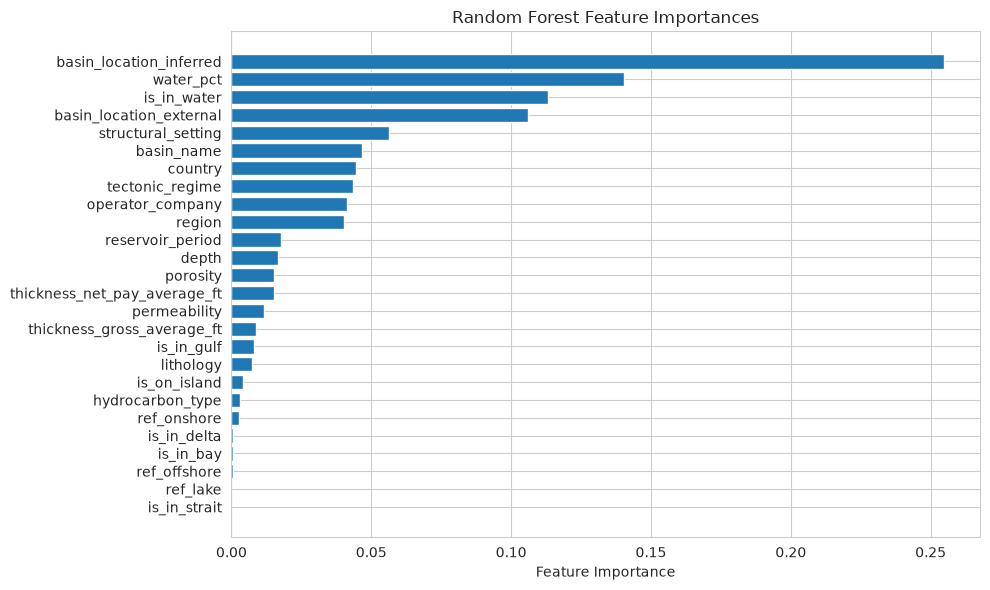

In [37]:
plt.figure(figsize=(10, 6))
plt.barh(imp_df['feature'], imp_df['importance'])
plt.xlabel('Feature Importance')
plt.title('Random Forest Feature Importances')
plt.tight_layout()
plt.show()

1. Самым значимым признаком оказался `basin_location_inferred` - это, по сути, расчитанное по месторождениям месторасположение бассейна.
2. Вторым по значимости оказался процент площади, занимаемый водой в радиусе 2км вокруг месторождения.
3. Дальше следует признак сообщающий, находится ли координата в воде.
4. `basin_location_external` - это справочный признак по залеганию бассейна.

Дальше следует группа признаков, добавляющая, в среднем, по 0.05 пунктов к значимости: название бассейна, страна, тектонический режим, оператор и регион. 

Интересно отметить, что признаки, построенные на названиях и гео-признаках (острова, заливы, дельты рек) тоже имеют некоторую значимость, хоть и маленькую.

### Отправка предсказания на соревнование

In [38]:
enc_feature_cols_test = [c for c in encoded_test_df.columns if c not in [target_col, *id_cols]]

In [39]:
test_X = encoded_test_df[enc_feature_cols_test]

In [40]:
random_forest_enc_y_pred = random_forest.predict(test_X)

In [41]:
submission_df = (pd.DataFrame(random_forest_enc_y_pred, columns=["Onshore/Offshore"]).reset_index())

In [42]:
submission_df['Onshore/Offshore'].value_counts()

Onshore/Offshore
1    97
0    36
Name: count, dtype: int64

In [43]:
# submission_df.to_csv("../data/submission_1.csv", index=False)

In [44]:
submitter = KaggleSubmitter(competition="classification-of-oil-and-gas")
submitter.auth()

In [45]:
submission_hash = "Submission 1: Random Forest ('n_estimators': 100, 'max_depth': 10, 'random_state': 42)"
# submitter.submit_entry(submission_hash=submission_hash, submission_path="../data/submission_1.csv")

In [46]:
attrs = ["date", "description", "publicScore", "ref"]

In [47]:
submission_result = submitter.get_submission_by_hash(submission_hash)
print(f"ref: {submission_result.ref}")
print(f"date: {submission_result.date}")
print(f"description: {submission_result.description}")
print(f"publicScore: {submission_result.public_score}")

ref: 54984521
date: 2026-07-25 20:52:13.680000
description: Submission 1: Random Forest ('n_estimators': 100, 'max_depth': 10, 'random_state': 42)
publicScore: 0.94916


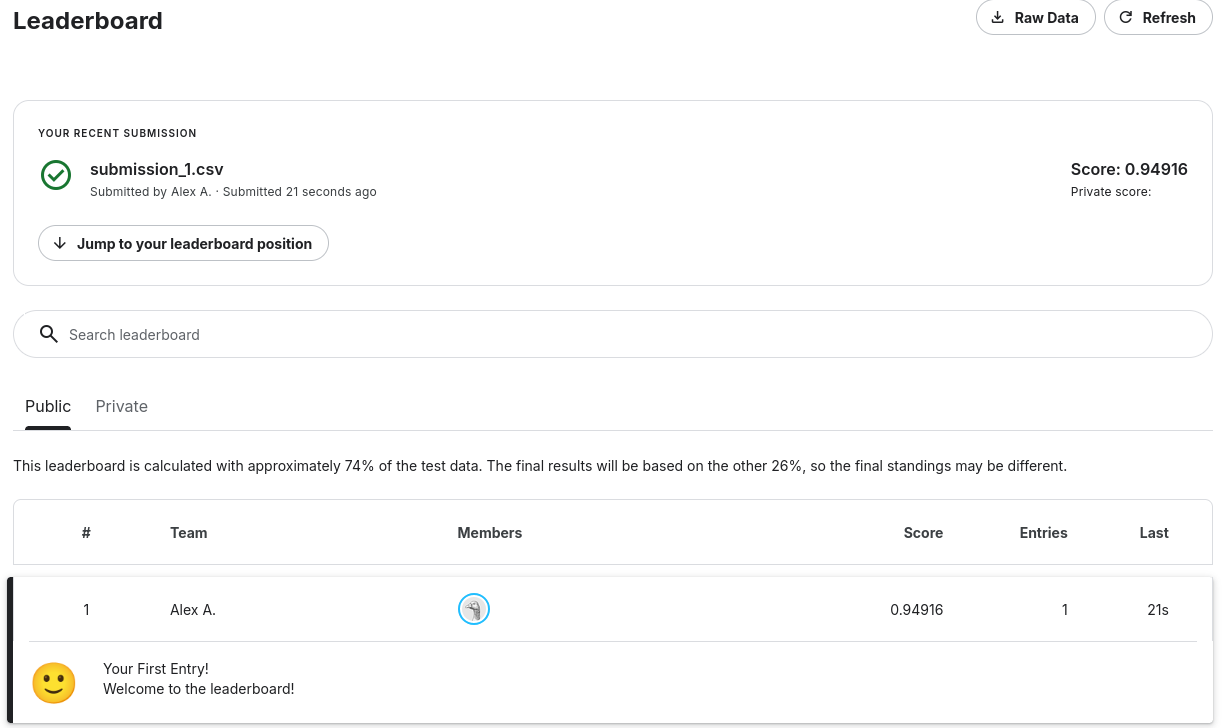

In [48]:
display(Image("../doc/img/submission_screenshot.png", width=500))

### Вывод к этапу обучения и отправке результатов
Submission 1 набрал publicScore=0.94916. Вероятно, в датасете были смешанные классы. 

Решающим фактором стало подробное ознакомление с предметной областью и изучение справочных материалов. Понимание предметной области позволило обогатить датасет данными из справочников, сформулировать признаки для бассейнов (бассейны могут залегать и под морем и под сушей, а информация об этом есть в обучающей выборке) и признаки, основанные на координатах:
1. Самым значимым признаком оказался `basin_location_inferred` - это, по сути, расчитанное по месторождениям месторасположение бассейна. Некоторые бассейны встречаются для разных месторождений по нескольку раз. Поэтому, удалось разработать признак, который указывает на то, как залегает бассейн.
2. Вторым по значимости оказался процент площади, занимаемый водой в радиусе 2км вокруг месторождения.
3. Дальше следует признак сообщающий, находится ли координата в воде.
4. На четвёртом месте находится `basin_location_external` - это справочный признак по залеганию бассейна.

Знакомство с данными помогло выявить сложные случаи - месторождения, отмеченные onshore/offshore, и те что находясь в окружении воды, тем не менее, являлись береговыми (в озере и на острове). Эти наблюдения помогли сформулировать дополнительные наборы признаков.

Выбор алгоритма оказался сложным, т.к. все модели показали индентичные скоры, а выбрать алгоритм удалось сравнив то, как модели ошибаются. Т.к. другие алгоритмы ошибались системно (неправильно классифицировали небольшую подгруппу смешанных меторождений), то выбор пал на модель на основе `RandomForestClassifier`, которая ошибалась, по большей части, случайно. 

Улучшить результат можно построив дополнительные признаки на основании признака TVD и справочника с бариметрическими данными для координат (GEBCO).